<a href="https://colab.research.google.com/github/ArthTechX/Diffusion-Language-Models/blob/main/week1_llada_moe_structured_proposal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 — LLaDA-MoE Baseline Reproducibility Notebook

This notebook is structured from the runnable Colab cells you shared and aligned with the **Week 1 deliverable** in the internship proposal:

> Reproduce a baseline run on one model/domain and add logging for per-timestep losses, teacher agreement, gate entropy, branch usage, and memory use.

Because free Google Colab T4 is limited, this notebook uses:

- **Model:** `inclusionAI/LLaDA-MoE-7B-A1B-Instruct`
- **GPU target:** Free Colab Tesla T4
- **Quantization:** 4-bit NF4 with `bitsandbytes`
- **Sequence length:** `MAX_LENGTH = 32`
- **Task:** small masked denoising-loss baseline
- **Logging:** CSV rows for target and retention domains across low/mid/high noise bins

Important limitation: this is a **baseline logging and debugging scaffold**, not full DG+LoRA/DiffusionGrow training.


## 0. Colab runtime setup

Before running:

1. Go to **Runtime → Change runtime type**
2. Select **GPU**
3. Run the cells in order

This notebook was structured for free Colab T4. If you get A100/L4, it should also work.


In [ ]:
!nvidia-smi

Tue Jun 30 07:58:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Install dependencies

Run this cell first.

After installation, do:

**Runtime → Restart session**

Then continue from Section 2. Restarting avoids import/version conflicts.


In [ ]:
!pip uninstall -y transformers tokenizers -q

!pip -q install --no-cache-dir \
  "transformers>=4.45.0,<5.0.0" \
  accelerate \
  bitsandbytes \
  safetensors \
  sentencepiece \
  einops \
  huggingface_hub \
  pandas \
  matplotlib \
  numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 130.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 138.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 250.9 MB/s eta 0:00:00


## 2. Imports and experiment configuration

This section defines the model, mask token, noise bins, output directory, and random seed.

For this LLaDA-MoE model, use:

```python
MASK_ID = 156895
```


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "inclusionAI/LLaDA-MoE-7B-A1B-Instruct"
MASK_ID = 156895

# Keep this small for free Colab T4.
MAX_LENGTH = 32

OUT_DIR = Path("/content/llada_moe_week1_baseline")
OUT_DIR.mkdir(parents=True, exist_ok=True)

NOISE_BINS = {
    "low_noise": 0.15,
    "mid_noise": 0.50,
    "high_noise": 0.85,
}

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA memory allocated GB:", torch.cuda.memory_allocated() / 1024**3)

print("MODEL_NAME:", MODEL_NAME)
print("MASK_ID:", MASK_ID)
print("MAX_LENGTH:", MAX_LENGTH)
print("OUT_DIR:", OUT_DIR)

CUDA available: True
GPU: Tesla T4
CUDA memory allocated GB: 0.0
MODEL_NAME: inclusionAI/LLaDA-MoE-7B-A1B-Instruct
MASK_ID: 156895
MAX_LENGTH: 32
OUT_DIR: /content/llada_moe_week1_baseline


## 3. Compatibility check

This catches the earlier RoPE issue:

```text
KeyError: 'default'
```

The model can load only if the installed `transformers` version has `"default"` inside `ROPE_INIT_FUNCTIONS`.


In [ ]:
import transformers
from transformers.modeling_rope_utils import ROPE_INIT_FUNCTIONS

print("Transformers version:", transformers.__version__)
print("Available RoPE keys:", list(ROPE_INIT_FUNCTIONS.keys()))

assert "default" in ROPE_INIT_FUNCTIONS, "Still broken: 'default' missing from ROPE_INIT_FUNCTIONS"
print("RoPE compatibility check passed.")

Transformers version: 4.57.6
Available RoPE keys: ['default', 'linear', 'dynamic', 'yarn', 'longrope', 'llama3']
RoPE compatibility check passed.


## 4. Load baseline model in 4-bit NF4

This is the Week 1 baseline model.

Expected result on free Colab T4:

- model loads on `cuda:0`
- memory footprint is around a few GB in 4-bit
- no training is done here


In [ ]:
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig

if not torch.cuda.is_available():
    raise RuntimeError("Please enable GPU in Colab: Runtime → Change runtime type → GPU")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

model = AutoModel.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    quantization_config=bnb_config,
    device_map="auto",
    max_memory={
        0: "13GiB",
        "cpu": "25GiB",
    },
    low_cpu_mem_usage=True,
)

model.eval()

print("Loaded:", MODEL_NAME)

if hasattr(model, "hf_device_map"):
    print("Device map:")
    print(model.hf_device_map)

try:
    print("Memory footprint GB:", model.get_memory_footprint() / 1024**3)
except Exception as e:
    print("Could not read memory footprint:", repr(e))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.72G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loaded: inclusionAI/LLaDA-MoE-7B-A1B-Instruct
Device map:
{'': 0}
Memory footprint GB: 4.325329065322876


## 5. Device and forward helper

This helper makes sure input tokens are placed on the same device as the model input embeddings.


In [ ]:
def get_input_device(model):
    try:
        return model.get_input_embeddings().weight.device
    except Exception:
        pass

    if hasattr(model, "device"):
        return model.device

    for p in model.parameters():
        return p.device

    return torch.device("cuda")


input_device = get_input_device(model)
print("Input device:", input_device)


@torch.no_grad()
def call_model_forward(input_ids):
    out = model(input_ids=input_ids)

    if hasattr(out, "logits"):
        return out.logits

    if isinstance(out, (tuple, list)):
        return out[0]

    return out

Input device: cuda:0


## 6. Smoke test: one forward pass

This verifies that the model not only loads, but also runs a real forward pass on free Colab T4.


In [ ]:
text = "Explain binary search in one sentence."

input_ids = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=MAX_LENGTH,
)["input_ids"].to(input_device)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

start = time.time()

with torch.no_grad():
    logits = call_model_forward(input_ids)

elapsed = time.time() - start

print("Forward pass successful.")
print("Input shape:", input_ids.shape)
print("Logits shape:", logits.shape)
print("Elapsed sec:", elapsed)
print("Peak GPU memory GB:", torch.cuda.max_memory_allocated() / 1024**3)

del logits
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Forward pass successful.
Input shape: torch.Size([1, 7])
Logits shape: torch.Size([1, 7, 157184])
Elapsed sec: 1.957292079925537
Peak GPU memory GB: 4.446753025054932


## 7. Week 1 toy datasets

The proposal asks for a matched baseline table and retention logging.

Here we use two small toy domains:

- `target_code_toy`: represents the adaptation/target domain
- `retention_general_toy`: represents general-domain retention data

Later you can replace these lists with samples from CodeParrot, BigPatent, math, economics, WikiText, or OpenWebText.


In [ ]:
TARGET_TEXTS = [
    "def add_numbers(a, b): return a + b",
    "Binary search repeatedly halves the search interval.",
    "The function computes the maximum subarray sum using dynamic programming.",
    "class Queue: def __init__(self): self.items = []",
]

RETENTION_TEXTS = [
    "The city library opens every morning.",
    "Students learn better when examples are clear and practice is consistent.",
    "A healthy diet includes fruits, vegetables, grains, and enough water.",
    "The history of science includes many discoveries made through careful experiments.",
]

print("Target examples:", len(TARGET_TEXTS))
print("Retention examples:", len(RETENTION_TEXTS))

Target examples: 4
Retention examples: 4


## 8. Masking and denoising-loss helpers

For each text and noise bin:

1. tokenize the clean text
2. randomly replace some tokens with `MASK_ID`
3. run the model
4. calculate loss only on masked positions
5. log both normal masked-token CE loss and LLaDA-style weighted loss

The weighted loss divides token loss by the mask probability, which makes losses across noise levels more comparable.


In [ ]:
def make_masked_input(clean_ids, mask_prob):
    rand = torch.rand(clean_ids.shape, device=clean_ids.device)

    # No padding is used for one-text-at-a-time evaluation, so all positions are valid.
    masked_indices = rand < mask_prob

    # Ensure at least one token is masked.
    if not masked_indices.any():
        masked_indices[0, -1] = True

    noisy_ids = torch.where(
        masked_indices,
        torch.full_like(clean_ids, MASK_ID),
        clean_ids,
    )

    p_mask = torch.full(
        clean_ids.shape,
        fill_value=float(mask_prob),
        dtype=torch.float32,
        device=clean_ids.device,
    )

    return noisy_ids, masked_indices, p_mask


def placeholder_diffusiongrow_metrics():
    # Vanilla LLaDA-MoE has no DiffusionGrow grown branches or routing gates.
    # These become real only after plugging in DiffusionGrow.
    return {
        "teacher_agreement": 1.0,
        "forgetting_vs_pretrained": float("nan"),
        "gate_entropy": float("nan"),
        "frozen_branch_usage": float("nan"),
        "trainable_branch_usage": float("nan"),
    }


@torch.no_grad()
def compute_denoising_loss(domain_name, text_id, text, noise_bin, mask_prob):
    input_ids = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )["input_ids"].to(input_device)

    noisy_ids, masked_indices, p_mask = make_masked_input(input_ids, mask_prob)

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    start = time.time()
    logits = call_model_forward(noisy_ids).float()
    elapsed = time.time() - start

    logits_masked = logits[masked_indices]
    labels_masked = input_ids[masked_indices]

    ce_loss = F.cross_entropy(logits_masked, labels_masked, reduction="mean")

    token_loss = F.cross_entropy(logits_masked, labels_masked, reduction="none")
    weighted_token_loss = token_loss / p_mask[masked_indices]
    weighted_loss = weighted_token_loss.sum() / (input_ids.shape[0] * input_ids.shape[1])

    extra = placeholder_diffusiongrow_metrics()

    row = {
        "seed": SEED,
        "model_name": MODEL_NAME,
        "quantization": "nf4_4bit",
        "max_length": MAX_LENGTH,
        "mask_id": MASK_ID,
        "domain": domain_name,
        "text_id": text_id,
        "text": text,
        "noise_bin": noise_bin,
        "mask_prob": mask_prob,
        "seq_len": int(input_ids.shape[1]),
        "masked_tokens": int(masked_indices.sum().item()),
        "ce_loss": float(ce_loss.detach().cpu()),
        "weighted_loss": float(weighted_loss.detach().cpu()),
        "peak_gpu_memory_gb": torch.cuda.max_memory_allocated() / 1024**3,
        "elapsed_sec": elapsed,
        **extra,
    }

    del input_ids, noisy_ids, masked_indices, p_mask, logits
    torch.cuda.empty_cache()

    return row

## 9. Run Week 1 baseline evaluation

This creates one CSV row per:

```text
domain × text × noise_bin
```

This is the main Week 1 logging table.


In [ ]:
rows = []

datasets = {
    "target_code_toy": TARGET_TEXTS,
    "retention_general_toy": RETENTION_TEXTS,
}

for domain_name, texts in datasets.items():
    for text_id, text in enumerate(texts):
        for noise_bin, mask_prob in NOISE_BINS.items():
            result = compute_denoising_loss(
                domain_name=domain_name,
                text_id=text_id,
                text=text,
                noise_bin=noise_bin,
                mask_prob=mask_prob,
            )
            rows.append(result)
            print({
                "domain": result["domain"],
                "noise_bin": result["noise_bin"],
                "ce_loss": round(result["ce_loss"], 4),
                "weighted_loss": round(result["weighted_loss"], 4),
                "masked_tokens": result["masked_tokens"],
                "peak_gpu_memory_gb": round(result["peak_gpu_memory_gb"], 4),
            })

df = pd.DataFrame(rows)

csv_path = OUT_DIR / "week1_llada_moe_eval_log.csv"
df.to_csv(csv_path, index=False)

print("Saved eval log:", csv_path)
df.head()

{'domain': 'target_code_toy', 'noise_bin': 'low_noise', 'ce_loss': 1.9359, 'weighted_loss': 2.3465, 'masked_tokens': 2, 'peak_gpu_memory_gb': 4.4482}
{'domain': 'target_code_toy', 'noise_bin': 'mid_noise', 'ce_loss': 5.2886, 'weighted_loss': 0.9616, 'masked_tokens': 1, 'peak_gpu_memory_gb': 4.4482}
{'domain': 'target_code_toy', 'noise_bin': 'high_noise', 'ce_loss': 6.2676, 'weighted_loss': 6.033, 'masked_tokens': 9, 'peak_gpu_memory_gb': 4.4555}
{'domain': 'target_code_toy', 'noise_bin': 'low_noise', 'ce_loss': 2.4206, 'weighted_loss': 4.0344, 'masked_tokens': 2, 'peak_gpu_memory_gb': 4.4468}
{'domain': 'target_code_toy', 'noise_bin': 'mid_noise', 'ce_loss': 4.7195, 'weighted_loss': 4.7195, 'masked_tokens': 4, 'peak_gpu_memory_gb': 4.4479}
{'domain': 'target_code_toy', 'noise_bin': 'high_noise', 'ce_loss': 9.2529, 'weighted_loss': 10.8858, 'masked_tokens': 8, 'peak_gpu_memory_gb': 4.4526}
{'domain': 'target_code_toy', 'noise_bin': 'low_noise', 'ce_loss': 0.0128, 'weighted_loss': 0.0142

,seed,model_name,quantization,max_length,mask_id,domain,text_id,text,noise_bin,mask_prob,...,masked_tokens,ce_loss,weighted_loss,peak_gpu_memory_gb,elapsed_sec,teacher_agreement,forgetting_vs_pretrained,gate_entropy,frozen_branch_usage,trainable_branch_usage
0,42,inclusionAI/LLaDA-MoE-7B-A1B-Instruct,nf4_4bit,32,156895,target_code_toy,0,"def add_numbers(a, b): return a + b",low_noise,0.15,...,2,1.935879,2.346520,4.448169,0.838031,1.0,NaN,NaN,NaN,NaN
1,42,inclusionAI/LLaDA-MoE-7B-A1B-Instruct,nf4_4bit,32,156895,target_code_toy,0,"def add_numbers(a, b): return a + b",mid_noise,0.50,...,1,5.288570,0.961558,4.448169,0.830752,1.0,NaN,NaN,NaN,NaN
2,42,inclusionAI/LLaDA-MoE-7B-A1B-Instruct,nf4_4bit,32,156895,target_code_toy,0,"def add_numbers(a, b): return a + b",high_noise,0.85,...,9,6.267580,6.032964,4.455490,0.797592,1.0,NaN,NaN,NaN,NaN
3,42,inclusionAI/LLaDA-MoE-7B-A1B-Instruct,nf4_4bit,32,156895,target_code_toy,1,Binary search repeatedly halves the search int...,low_noise,0.15,...,2,2.420620,4.034366,4.446782,0.864491,1.0,NaN,NaN,NaN,NaN
4,42,inclusionAI/LLaDA-MoE-7B-A1B-Instruct,nf4_4bit,32,156895,target_code_toy,1,Binary search repeatedly halves the search int...,mid_noise,0.50,...,4,4.719543,4.719543,4.447878,0.842324,1.0,NaN,NaN,NaN,NaN


## 10. Summary tables

These are the tables you can use in your Week 1 reproducibility report.


In [ ]:
summary_by_domain = (
    df.groupby("domain")
    .agg(
        mean_ce_loss=("ce_loss", "mean"),
        mean_weighted_loss=("weighted_loss", "mean"),
        mean_teacher_agreement=("teacher_agreement", "mean"),
        max_gpu_memory_gb=("peak_gpu_memory_gb", "max"),
        mean_elapsed_sec=("elapsed_sec", "mean"),
    )
    .reset_index()
)

summary_by_noise = (
    df.groupby(["domain", "noise_bin"])
    .agg(
        mean_ce_loss=("ce_loss", "mean"),
        mean_weighted_loss=("weighted_loss", "mean"),
        mean_masked_tokens=("masked_tokens", "mean"),
        max_gpu_memory_gb=("peak_gpu_memory_gb", "max"),
    )
    .reset_index()
)

domain_summary_path = OUT_DIR / "week1_summary_by_domain.csv"
noise_summary_path = OUT_DIR / "week1_summary_by_noise.csv"

summary_by_domain.to_csv(domain_summary_path, index=False)
summary_by_noise.to_csv(noise_summary_path, index=False)

print("Saved:", domain_summary_path)
print("Saved:", noise_summary_path)

display(summary_by_domain)
display(summary_by_noise)

Saved: /content/llada_moe_week1_baseline/week1_summary_by_domain.csv
Saved: /content/llada_moe_week1_baseline/week1_summary_by_noise.csv


,domain,mean_ce_loss,mean_weighted_loss,mean_teacher_agreement,max_gpu_memory_gb,mean_elapsed_sec
0,retention_general_toy,4.174577,4.307071,1.0,4.459589,0.859734
1,target_code_toy,4.223890,4.462818,1.0,4.459589,0.812499


,domain,noise_bin,mean_ce_loss,mean_weighted_loss,mean_masked_tokens,max_gpu_memory_gb
0,retention_general_toy,high_noise,6.826973,7.104041,9.50,4.459589
1,retention_general_toy,low_noise,2.371022,2.957838,2.50,4.451391
2,retention_general_toy,mid_noise,3.325737,2.859334,4.75,4.452562
3,target_code_toy,high_noise,6.957373,7.674553,10.00,4.459589
4,target_code_toy,low_noise,2.125311,3.187990,2.25,4.449925
5,target_code_toy,mid_noise,3.588984,2.525912,4.50,4.453733


## 11. Plot noise-bin loss

Expected pattern: high-noise loss is usually higher because the model has less context.


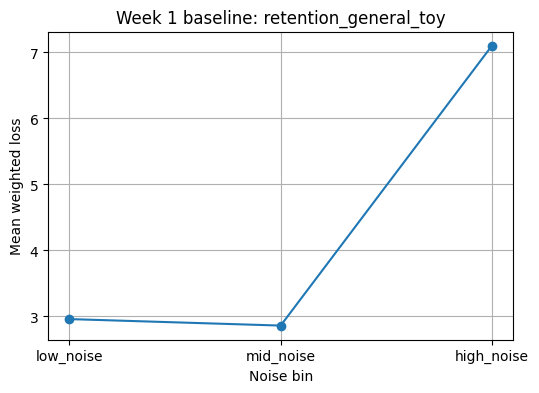

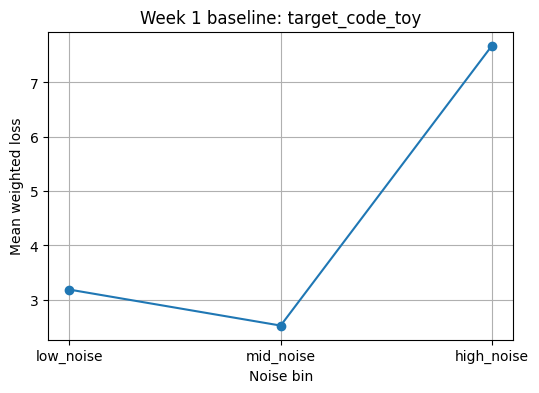

In [ ]:
noise_order = ["low_noise", "mid_noise", "high_noise"]

for domain_name in summary_by_noise["domain"].unique():
    sub = summary_by_noise[summary_by_noise["domain"] == domain_name].copy()
    sub["noise_bin"] = pd.Categorical(sub["noise_bin"], categories=noise_order, ordered=True)
    sub = sub.sort_values("noise_bin")

    plt.figure(figsize=(6, 4))
    plt.plot(sub["noise_bin"], sub["mean_weighted_loss"], marker="o")
    plt.xlabel("Noise bin")
    plt.ylabel("Mean weighted loss")
    plt.title(f"Week 1 baseline: {domain_name}")
    plt.grid(True)
    plt.show()

## 12. Save reproducibility report

This creates a small JSON report with the exact setup and output files.


In [ ]:
report = {
    "week": 1,
    "task": "Baseline LLaDA-MoE masked denoising-loss logging",
    "model_name": MODEL_NAME,
    "mask_id": MASK_ID,
    "max_length": MAX_LENGTH,
    "quantization": "4-bit NF4",
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "noise_bins": NOISE_BINS,
    "target_examples": len(TARGET_TEXTS),
    "retention_examples": len(RETENTION_TEXTS),
    "eval_log_csv": str(csv_path),
    "summary_by_domain_csv": str(domain_summary_path),
    "summary_by_noise_csv": str(noise_summary_path),
    "max_gpu_memory_gb": float(df["peak_gpu_memory_gb"].max()),
    "mean_target_weighted_loss": float(summary_by_domain.loc[summary_by_domain["domain"] == "target_code_toy", "mean_weighted_loss"].iloc[0]),
    "mean_retention_weighted_loss": float(summary_by_domain.loc[summary_by_domain["domain"] == "retention_general_toy", "mean_weighted_loss"].iloc[0]),
    "status": "PASS: model loaded, forward pass ran, baseline denoising losses logged",
}

report_path = OUT_DIR / "week1_reproducibility_report.json"

with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("Saved report:", report_path)
report

Saved report: /content/llada_moe_week1_baseline/week1_reproducibility_report.json


{'week': 1,
 'task': 'Baseline LLaDA-MoE masked denoising-loss logging',
 'model_name': 'inclusionAI/LLaDA-MoE-7B-A1B-Instruct',
 'mask_id': 156895,
 'max_length': 32,
 'quantization': '4-bit NF4',
 'gpu': 'Tesla T4',
 'noise_bins': {'low_noise': 0.15, 'mid_noise': 0.5, 'high_noise': 0.85},
 'target_examples': 4,
 'retention_examples': 4,
 'eval_log_csv': '/content/llada_moe_week1_baseline/week1_llada_moe_eval_log.csv',
 'summary_by_domain_csv': '/content/llada_moe_week1_baseline/week1_summary_by_domain.csv',
 'summary_by_noise_csv': '/content/llada_moe_week1_baseline/week1_summary_by_noise.csv',
 'max_gpu_memory_gb': 4.459589004516602,
 'mean_target_weighted_loss': 4.462818424838285,
 'mean_retention_weighted_loss': 4.307070950667064,
 'status': 'PASS: model loaded, forward pass ran, baseline denoising losses logged'}

## 13. Week 1 conclusion template

After the notebook runs, you can paste this into your internship progress document:

```text
Week 1 reproduced a small LLaDA-family baseline using inclusionAI/LLaDA-MoE-7B-A1B-Instruct on a free Google Colab T4 GPU. The model loaded successfully using 4-bit NF4 quantization, completed a short forward pass, and produced masked denoising-loss logs across low, mid, and high noise bins for both target-domain toy code examples and general retention examples. The run saved per-example CSV logs, domain summaries, noise-bin summaries, and a reproducibility JSON report. DiffusionGrow-specific fields such as gate entropy and frozen-branch usage are currently placeholders because this baseline uses vanilla LLaDA-MoE without grown branches.
```


## 14. Next step for Week 2

The Week 2 task can build on this notebook by adding drift probes:

- frozen model vs warm-start probe model
- hidden-state drift per layer
- logit KL drift per noise bin
- layer ranking JSON for future DiffusionGrow growth selection

For free Colab, develop Week 2 logic on a small surrogate model first, then reuse the same CSV/JSON structure here for the LLaDA-family model when stronger GPU is available.


In [ ]:
!pip -q install peft

In [ ]:
import peft
print("peft version:", peft.__version__)

peft version: 0.19.1


In [ ]:
import os
import json
import time
import random
from pathlib import Path

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

WEEK2_DIR = Path("/content/week2_dasg_drift_probe")
WEEK2_DIR.mkdir(parents=True, exist_ok=True)

MAX_LENGTH = 32
MASK_ID = 156895

NOISE_BINS = {
    "low_noise": 0.15,
    "mid_noise": 0.50,
    "high_noise": 0.85,
}

TARGET_TEXTS = [
    "def add_numbers(a, b): return a + b",
    "for i in range(n): total += arr[i]",
    "A binary search repeatedly halves the search interval.",
    "The function computes the maximum subarray sum using dynamic programming.",
    "class Queue: def __init__(self): self.items = []",
]

RETENTION_TEXTS = [
    "The city library opens every morning.",
    "Students learn better when examples are clear and practice is consistent.",
    "A healthy diet includes fruits, vegetables, grains, and enough water.",
]

print("Week 2 output dir:", WEEK2_DIR)
print("GPU:", torch.cuda.get_device_name(0))

Week 2 output dir: /content/week2_dasg_drift_probe
GPU: Tesla T4


In [ ]:
assert "model" in globals(), "model is not loaded. Run Week 1 model loading cell first."
assert "tokenizer" in globals(), "tokenizer is not loaded. Run Week 1 model loading cell first."

def get_input_device(model):
    try:
        return model.get_input_embeddings().weight.device
    except Exception:
        pass

    if hasattr(model, "device"):
        return model.device

    for p in model.parameters():
        return p.device

    return torch.device("cuda")

input_device = get_input_device(model)

print("Model exists:", model is not None)
print("Tokenizer exists:", tokenizer is not None)
print("Input device:", input_device)

Model exists: True
Tokenizer exists: True
Input device: cuda:0


In [ ]:
def encode_text(text):
    batch = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )

    input_ids = batch["input_ids"].to(input_device)

    if "attention_mask" in batch:
        attention_mask = batch["attention_mask"].to(input_device)
    else:
        attention_mask = torch.ones_like(input_ids)

    return input_ids, attention_mask


def make_masked_input(clean_ids, attention_mask, mask_prob):
    rand = torch.rand(clean_ids.shape, device=clean_ids.device)
    valid = attention_mask.bool()

    masked_indices = (rand < mask_prob) & valid

    if not masked_indices.any():
        masked_indices[0, -1] = True

    noisy_ids = torch.where(
        masked_indices,
        torch.full_like(clean_ids, MASK_ID),
        clean_ids,
    )

    return noisy_ids, masked_indices


def get_logits_from_output(out):
    if hasattr(out, "logits"):
        return out.logits

    if isinstance(out, (tuple, list)):
        return out[0]

    return out


def forward_logits(input_ids):
    out = model(input_ids=input_ids)
    return get_logits_from_output(out)


def forward_with_hidden_states(input_ids):
    """
    Returns logits and hidden states.

    This first tries output_hidden_states=True.
    If the model remote code does not support it, this cell will tell us clearly.
    """
    out = model(
        input_ids=input_ids,
        output_hidden_states=True,
        return_dict=True,
    )

    logits = get_logits_from_output(out)

    if not hasattr(out, "hidden_states") or out.hidden_states is None:
        raise RuntimeError(
            "Model did not return hidden_states. We need hook-based extraction."
        )

    return logits, out.hidden_states


def gpu_mem_gb():
    return torch.cuda.max_memory_allocated() / 1024**3

In [ ]:
text = "Binary search repeatedly halves the search interval."
input_ids, attention_mask = encode_text(text)

noisy_ids, masked_indices = make_masked_input(
    input_ids,
    attention_mask,
    mask_prob=0.50,
)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

with torch.no_grad():
    logits, hidden_states = forward_with_hidden_states(noisy_ids)

print("Hidden states supported.")
print("Logits shape:", logits.shape)
print("Number of hidden-state tensors:", len(hidden_states))
print("Hidden state 0 shape:", hidden_states[0].shape)
print("Peak GPU memory GB:", gpu_mem_gb())

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Hidden states supported.
Logits shape: torch.Size([1, 8, 157184])
Number of hidden-state tensors: 17
Hidden state 0 shape: torch.Size([1, 8, 2048])
Peak GPU memory GB: 4.447208404541016


In [ ]:
def find_lora_target_modules(model):
    candidate_suffixes = {
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "query",
        "key",
        "value",
        "dense",
    }

    found = set()

    for name, module in model.named_modules():
        cls_name = module.__class__.__name__.lower()

        if "linear" in cls_name:
            leaf = name.split(".")[-1]

            if leaf in candidate_suffixes:
                found.add(leaf)

    # Prefer attention projection modules if available.
    preferred = [x for x in ["q_proj", "k_proj", "v_proj", "o_proj"] if x in found]

    if preferred:
        return preferred

    if found:
        return sorted(found)

    raise RuntimeError("No suitable LoRA target modules found. Print model modules manually.")

target_modules = find_lora_target_modules(model)

print("LoRA target modules:", target_modules)

LoRA target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj']


In [ ]:
from peft import LoraConfig, get_peft_model

# Freeze base model parameters first.
for p in model.parameters():
    p.requires_grad = False

lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

print("LoRA probe added.")

trainable params: 1,048,576 || all params: 7,357,929,472 || trainable%: 0.0143
LoRA probe added.


In [ ]:
TRAIN_STEPS = 10
LR = 2e-4

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
)

model.train()

train_log = []

for step in range(TRAIN_STEPS):
    text = random.choice(TARGET_TEXTS)
    mask_prob = random.choice(list(NOISE_BINS.values()))

    input_ids, attention_mask = encode_text(text)

    noisy_ids, masked_indices = make_masked_input(
        input_ids,
        attention_mask,
        mask_prob,
    )

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    logits = forward_logits(noisy_ids).float()

    logits_masked = logits[masked_indices]
    labels_masked = input_ids[masked_indices]

    ce_loss = F.cross_entropy(logits_masked, labels_masked)
    weighted_loss = ce_loss / mask_prob

    optimizer.zero_grad()
    weighted_loss.backward()
    optimizer.step()

    row = {
        "step": step,
        "text": text,
        "mask_prob": mask_prob,
        "ce_loss": float(ce_loss.detach().cpu()),
        "weighted_loss": float(weighted_loss.detach().cpu()),
        "peak_gpu_memory_gb": gpu_mem_gb(),
    }

    train_log.append(row)

    print(row)

train_df = pd.DataFrame(train_log)
train_path = WEEK2_DIR / "week2_lora_probe_train_log.csv"
train_df.to_csv(train_path, index=False)

model.eval()

print("Saved:", train_path)
print("LoRA probe warm-start complete.")

{'step': 0, 'text': 'def add_numbers(a, b): return a + b', 'mask_prob': 0.15, 'ce_loss': 7.181066036224365, 'weighted_loss': 47.87377166748047, 'peak_gpu_memory_gb': 4.498869895935059}
{'step': 1, 'text': 'A binary search repeatedly halves the search interval.', 'mask_prob': 0.15, 'ce_loss': 3.458376407623291, 'weighted_loss': 23.05584144592285, 'peak_gpu_memory_gb': 4.50565242767334}
{'step': 2, 'text': 'for i in range(n): total += arr[i]', 'mask_prob': 0.15, 'ce_loss': 1.0403118133544922, 'weighted_loss': 6.9354119300842285, 'peak_gpu_memory_gb': 4.51290225982666}
{'step': 3, 'text': 'def add_numbers(a, b): return a + b', 'mask_prob': 0.85, 'ce_loss': 7.0123443603515625, 'weighted_loss': 8.24981689453125, 'peak_gpu_memory_gb': 4.5226922035217285}
{'step': 4, 'text': 'class Queue: def __init__(self): self.items = []', 'mask_prob': 0.15, 'ce_loss': 1.1603409051895142, 'weighted_loss': 7.735605716705322, 'peak_gpu_memory_gb': 4.526684761047363}
{'step': 5, 'text': 'class Queue: def __in

In [ ]:
from contextlib import nullcontext

def adapter_disabled_context(model):
    if hasattr(model, "disable_adapter"):
        return model.disable_adapter()
    return nullcontext()


@torch.no_grad()
def compute_base_and_probe_outputs(noisy_ids):
    """
    Base output = model with LoRA adapter disabled.
    Probe output = model with LoRA adapter enabled.
    """

    with adapter_disabled_context(model):
        base_logits, base_hidden = forward_with_hidden_states(noisy_ids)

    probe_logits, probe_hidden = forward_with_hidden_states(noisy_ids)

    return base_logits, base_hidden, probe_logits, probe_hidden


@torch.no_grad()
def compute_drift_for_text(domain, text, noise_bin, mask_prob):
    input_ids, attention_mask = encode_text(text)

    noisy_ids, masked_indices = make_masked_input(
        input_ids,
        attention_mask,
        mask_prob,
    )

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_logits, base_hidden, probe_logits, probe_hidden = compute_base_and_probe_outputs(noisy_ids)

    base_logits = base_logits.float()
    probe_logits = probe_logits.float()

    if masked_indices.sum().item() > 0:
        base_log_probs = F.log_softmax(base_logits[masked_indices], dim=-1)
        probe_log_probs = F.log_softmax(probe_logits[masked_indices], dim=-1)
        base_probs = base_log_probs.exp()

        # KL(base || probe)
        logit_kl = F.kl_div(
            probe_log_probs,
            base_probs,
            reduction="batchmean",
        ).item()
    else:
        logit_kl = float("nan")

    rows = []

    valid = attention_mask.bool()

    for hidden_idx, (h_base, h_probe) in enumerate(zip(base_hidden, probe_hidden)):
        # hidden_idx = 0 is usually embedding output.
        # transformer block id starts from hidden_idx - 1.
        if hidden_idx == 0:
            block_id = -1
        else:
            block_id = hidden_idx - 1

        diff = (h_probe.float() - h_base.float()) ** 2

        valid_expanded = valid.unsqueeze(-1).expand_as(diff)
        hidden_drift = diff[valid_expanded].mean().item()

        rows.append({
            "domain": domain,
            "text": text,
            "noise_bin": noise_bin,
            "mask_prob": mask_prob,
            "hidden_state_index": hidden_idx,
            "block_id": block_id,
            "hidden_drift": hidden_drift,
            "logit_kl": logit_kl,
            "combined_drift": hidden_drift + logit_kl,
            "masked_tokens": int(masked_indices.sum().item()),
            "peak_gpu_memory_gb": gpu_mem_gb(),
        })

    return rows

In [ ]:
drift_rows = []

for text in TARGET_TEXTS:
    for noise_bin, mask_prob in NOISE_BINS.items():
        drift_rows.extend(
            compute_drift_for_text(
                domain="target_code_toy",
                text=text,
                noise_bin=noise_bin,
                mask_prob=mask_prob,
            )
        )

for text in RETENTION_TEXTS:
    for noise_bin, mask_prob in NOISE_BINS.items():
        drift_rows.extend(
            compute_drift_for_text(
                domain="retention_general_toy",
                text=text,
                noise_bin=noise_bin,
                mask_prob=mask_prob,
            )
        )

drift_df = pd.DataFrame(drift_rows)

drift_path = WEEK2_DIR / "week2_drift_scores.csv"
drift_df.to_csv(drift_path, index=False)

print("Saved:", drift_path)
display(drift_df.head())
print("Rows:", len(drift_df))

Saved: /content/week2_dasg_drift_probe/week2_drift_scores.csv


,domain,text,noise_bin,mask_prob,hidden_state_index,block_id,hidden_drift,logit_kl,combined_drift,masked_tokens,peak_gpu_memory_gb
0,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,0,-1,0.000000e+00,0.701594,0.701594,2,4.492122
1,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,1,0,1.836972e-09,0.701594,0.701594,2,4.492122
2,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,2,1,2.166238e-07,0.701594,0.701594,2,4.492122
3,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,3,2,6.971062e-07,0.701594,0.701594,2,4.492122
4,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,4,3,2.006096e-06,0.701594,0.701596,2,4.492122


Rows: 408


In [ ]:
target_drift = drift_df[
    (drift_df["domain"] == "target_code_toy") &
    (drift_df["block_id"] >= 0)
]

rank_df = (
    target_drift
    .groupby("block_id")
    .agg(
        mean_hidden_drift=("hidden_drift", "mean"),
        mean_logit_kl=("logit_kl", "mean"),
        mean_combined_drift=("combined_drift", "mean"),
        max_combined_drift=("combined_drift", "max"),
    )
    .reset_index()
    .sort_values("mean_combined_drift", ascending=False)
)

rank_path = WEEK2_DIR / "week2_layer_ranking.csv"
rank_df.to_csv(rank_path, index=False)

print("Saved:", rank_path)
display(rank_df)

Saved: /content/week2_dasg_drift_probe/week2_layer_ranking.csv


,block_id,mean_hidden_drift,mean_logit_kl,mean_combined_drift,max_combined_drift
15,15,1.184030e+01,0.45993,12.300235,38.426057
14,14,7.454164e-01,0.45993,1.205347,3.556310
13,13,1.796510e-01,0.45993,0.639581,2.329012
12,12,1.054889e-01,0.45993,0.565419,2.128069
11,11,6.417256e-02,0.45993,0.524103,1.695090
10,10,5.777934e-02,0.45993,0.517710,1.679100
9,9,5.593324e-02,0.45993,0.515864,1.675199
8,8,1.438180e-02,0.45993,0.474312,1.319686
7,7,8.225437e-04,0.45993,0.460753,1.248764
6,6,6.472647e-05,0.45993,0.459995,1.245023


In [ ]:
budget_ratio = 0.33

num_blocks = rank_df["block_id"].nunique()
top_m = max(1, int(num_blocks * budget_ratio))

selected_layers = rank_df.head(top_m)["block_id"].astype(int).tolist()

selection = {
    "method": "DASG_week2_lora_probe",
    "model_name": MODEL_NAME,
    "mask_id": MASK_ID,
    "budget_ratio": budget_ratio,
    "num_blocks": int(num_blocks),
    "top_m": int(top_m),
    "selected_layers": selected_layers,
    "selection_rule": "mean_hidden_drift_plus_logit_kl",
    "notes": "Selected from target-domain drift using LoRA warm-start probe on free Colab T4.",
}

selection_path = WEEK2_DIR / "selected_grown_layers.json"

with open(selection_path, "w") as f:
    json.dump(selection, f, indent=2)

print("Saved:", selection_path)
print(json.dumps(selection, indent=2))

Saved: /content/week2_dasg_drift_probe/selected_grown_layers.json
{
  "method": "DASG_week2_lora_probe",
  "model_name": "inclusionAI/LLaDA-MoE-7B-A1B-Instruct",
  "mask_id": 156895,
  "budget_ratio": 0.33,
  "num_blocks": 16,
  "top_m": 5,
  "selected_layers": [
    15,
    14,
    13,
    12,
    11
  ],
  "selection_rule": "mean_hidden_drift_plus_logit_kl",
  "notes": "Selected from target-domain drift using LoRA warm-start probe on free Colab T4."
}


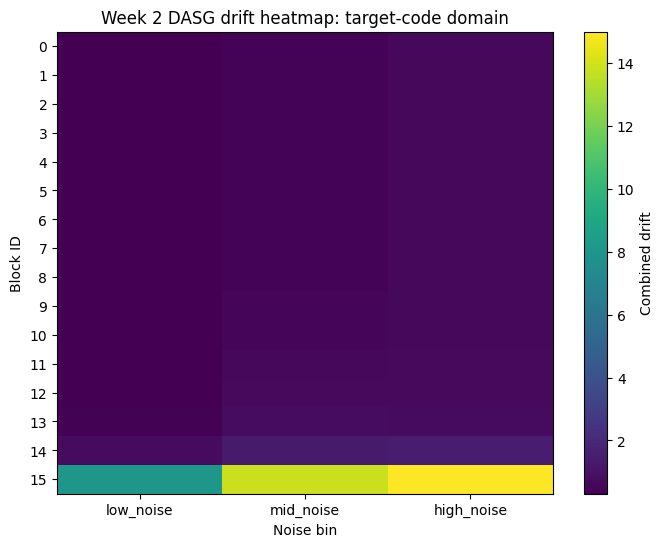

Saved heatmap values: /content/week2_dasg_drift_probe/week2_drift_heatmap_values.csv


In [ ]:
heatmap_df = target_drift.copy()

pivot = heatmap_df.pivot_table(
    index="block_id",
    columns="noise_bin",
    values="combined_drift",
    aggfunc="mean",
)

pivot = pivot[["low_noise", "mid_noise", "high_noise"]]

plt.figure(figsize=(8, 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Combined drift")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("Noise bin")
plt.ylabel("Block ID")
plt.title("Week 2 DASG drift heatmap: target-code domain")
plt.show()

heatmap_path = WEEK2_DIR / "week2_drift_heatmap_values.csv"
pivot.to_csv(heatmap_path)

print("Saved heatmap values:", heatmap_path)

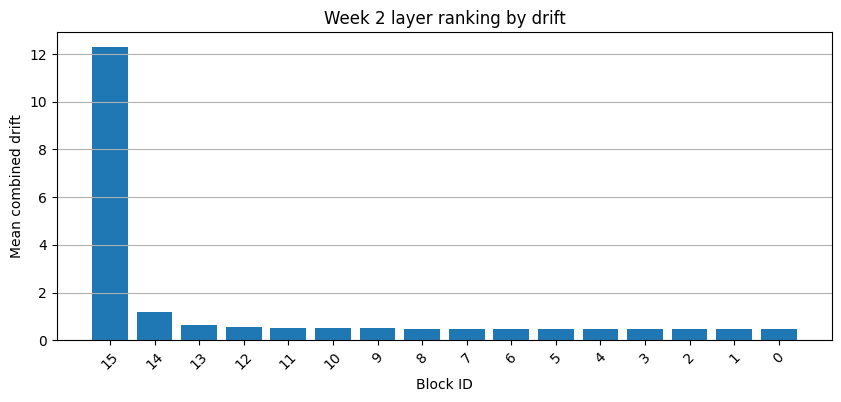

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(rank_df["block_id"].astype(str), rank_df["mean_combined_drift"])
plt.xlabel("Block ID")
plt.ylabel("Mean combined drift")
plt.title("Week 2 layer ranking by drift")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [ ]:
week2_report = {
    "week": 2,
    "task": "DASG drift probe",
    "model": MODEL_NAME,
    "gpu": torch.cuda.get_device_name(0),
    "max_length": MAX_LENGTH,
    "lora_train_steps": TRAIN_STEPS,
    "outputs": {
        "train_log": str(train_path),
        "drift_scores": str(drift_path),
        "layer_ranking": str(rank_path),
        "selected_layers": str(selection_path),
        "heatmap_values": str(heatmap_path),
    },
    "selected_layers": selected_layers,
    "notes": (
        "Implemented hidden-state drift, logit KL drift, and layer ranking across "
        "low/mid/high noise bins. This is a T4-friendly LoRA-probe version of DASG. "
        "Final DiffusionGrow integration will use selected_grown_layers.json."
    ),
}

report_path = WEEK2_DIR / "week2_reproducibility_report.json"

with open(report_path, "w") as f:
    json.dump(week2_report, f, indent=2)

print("Saved:", report_path)
print(json.dumps(week2_report, indent=2))

Saved: /content/week2_dasg_drift_probe/week2_reproducibility_report.json
{
  "week": 2,
  "task": "DASG drift probe",
  "model": "inclusionAI/LLaDA-MoE-7B-A1B-Instruct",
  "gpu": "Tesla T4",
  "max_length": 32,
  "lora_train_steps": 10,
  "outputs": {
    "train_log": "/content/week2_dasg_drift_probe/week2_lora_probe_train_log.csv",
    "drift_scores": "/content/week2_dasg_drift_probe/week2_drift_scores.csv",
    "layer_ranking": "/content/week2_dasg_drift_probe/week2_layer_ranking.csv",
    "selected_layers": "/content/week2_dasg_drift_probe/selected_grown_layers.json",
    "heatmap_values": "/content/week2_dasg_drift_probe/week2_drift_heatmap_values.csv"
  },
  "selected_layers": [
    15,
    14,
    13,
    12,
    11
  ],
  "notes": "Implemented hidden-state drift, logit KL drift, and layer ranking across low/mid/high noise bins. This is a T4-friendly LoRA-probe version of DASG. Final DiffusionGrow integration will use selected_grown_layers.json."
}


In [ ]:
week 2 done

In [ ]:
!pip -q install \
  "transformers>=4.45.0,<5.0.0" \
  "bitsandbytes>=0.46.1" \
  accelerate \
  peft \
  safetensors \
  sentencepiece \
  einops \
  pandas \
  matplotlib \
  numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "inclusionAI/LLaDA-MoE-7B-A1B-Instruct"
MASK_ID = 156895
MAX_LENGTH = 32

WEEK3_DIR = Path("/content/week3_dasg_sweeps")
WEEK3_DIR.mkdir(parents=True, exist_ok=True)

NOISE_BINS = {
    "low_noise": 0.15,
    "mid_noise": 0.50,
    "high_noise": 0.85,
}

TARGET_TEXTS = [
    "def add_numbers(a, b): return a + b",
    "for i in range(n): total += arr[i]",
    "A binary search repeatedly halves the search interval.",
    "The function computes the maximum subarray sum using dynamic programming.",
    "class Queue: def __init__(self): self.items = []",
]

RETENTION_TEXTS = [
    "The city library opens every morning.",
    "Students learn better when examples are clear and practice is consistent.",
    "A healthy diet includes fruits, vegetables, grains, and enough water.",
]

DASG_SELECTED_LAYERS = [15, 14, 13, 12, 11]

TRAIN_STEPS = 5
LR = 2e-4

print("Week 3 dir:", WEEK3_DIR)
print("GPU:", torch.cuda.get_device_name(0))

Week 3 dir: /content/week3_dasg_sweeps
GPU: Tesla T4


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

print("Tokenizer loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Tokenizer loaded.


In [ ]:
def cleanup_model():
    global model

    try:
        del model
    except Exception:
        pass

    gc.collect()
    torch.cuda.empty_cache()


def load_base_model():
    cleanup_model()

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    base = AutoModel.from_pretrained(
        MODEL_NAME,
        trust_remote_code=True,
        quantization_config=bnb_config,
        device_map="auto",
        max_memory={
            0: "13GiB",
            "cpu": "25GiB",
        },
        low_cpu_mem_usage=True,
    )

    base.eval()

    return base


def get_input_device(model):
    try:
        return model.get_input_embeddings().weight.device
    except Exception:
        pass

    if hasattr(model, "device"):
        return model.device

    for p in model.parameters():
        return p.device

    return torch.device("cuda")

In [ ]:
def encode_text(text, model):
    input_device = get_input_device(model)

    batch = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )

    input_ids = batch["input_ids"].to(input_device)

    if "attention_mask" in batch:
        attention_mask = batch["attention_mask"].to(input_device)
    else:
        attention_mask = torch.ones_like(input_ids)

    return input_ids, attention_mask


def make_masked_input(clean_ids, attention_mask, mask_prob):
    rand = torch.rand(clean_ids.shape, device=clean_ids.device)
    valid = attention_mask.bool()

    masked_indices = (rand < mask_prob) & valid

    if not masked_indices.any():
        masked_indices[0, -1] = True

    noisy_ids = torch.where(
        masked_indices,
        torch.full_like(clean_ids, MASK_ID),
        clean_ids,
    )

    return noisy_ids, masked_indices


def get_logits_from_output(out):
    if hasattr(out, "logits"):
        return out.logits

    if isinstance(out, (tuple, list)):
        return out[0]

    return out


@torch.no_grad()
def eval_loss(model, texts, domain_name):
    model.eval()

    rows = []

    for text in texts:
        for noise_bin, mask_prob in NOISE_BINS.items():
            input_ids, attention_mask = encode_text(text, model)

            noisy_ids, masked_indices = make_masked_input(
                input_ids,
                attention_mask,
                mask_prob,
            )

            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()

            start = time.time()

            with torch.no_grad():
                out = model(input_ids=noisy_ids)
                logits = get_logits_from_output(out).float()

            elapsed = time.time() - start

            logits_masked = logits[masked_indices]
            labels_masked = input_ids[masked_indices]

            ce_loss = F.cross_entropy(logits_masked, labels_masked)
            weighted_loss = ce_loss / mask_prob

            rows.append({
                "domain": domain_name,
                "text": text,
                "noise_bin": noise_bin,
                "mask_prob": mask_prob,
                "ce_loss": float(ce_loss.detach().cpu()),
                "weighted_loss": float(weighted_loss.detach().cpu()),
                "masked_tokens": int(masked_indices.sum().item()),
                "peak_gpu_memory_gb": torch.cuda.max_memory_allocated() / 1024**3,
                "elapsed_sec": elapsed,
            })

            del noisy_ids, masked_indices, logits
            torch.cuda.empty_cache()

    return rows

In [ ]:
model = load_base_model()

print("Base model loaded.")

for name, module in list(model.named_modules())[:50]:
    print(name, "->", module.__class__.__name__)

print("Memory footprint GB:", model.get_memory_footprint() / 1024**3)

config.json: 0.00B [00:00, ?B/s]

configuration_lladamoe.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/inclusionAI/LLaDA-MoE-7B-A1B-Instruct:
- configuration_lladamoe.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_lladamoe.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/inclusionAI/LLaDA-MoE-7B-A1B-Instruct:
- modeling_lladamoe.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Base model loaded.
 -> LLaDAMoEModelLM
model -> LLaDAMoEModel
model.embed_tokens -> Embedding
model.layers -> ModuleList
model.layers.0 -> LLaDAMoEDecoderLayer
model.layers.0.self_attn -> LLaDAMoESdpaAttention
model.layers.0.self_attn.q_proj -> Linear4bit
model.layers.0.self_attn.k_proj -> Linear4bit
model.layers.0.self_attn.v_proj -> Linear4bit
model.layers.0.self_attn.o_proj -> Linear4bit
model.layers.0.self_attn.q_norm -> LLaDAMoERMSNorm
model.layers.0.self_attn.k_norm -> LLaDAMoERMSNorm
model.layers.0.mlp -> LLaDAMoESparseMoeBlock
model.layers.0.mlp.gate -> Linear4bit
model.layers.0.mlp.experts -> ModuleList
model.layers.0.mlp.experts.0 -> LLaDAMoEMLP
model.layers.0.mlp.experts.0.gate_proj -> Linear4bit
model.layers.0.mlp.experts.0.up_proj -> Linear4bit
model.layers.0.mlp.experts.0.down_proj -> Linear4bit
model.layers.0.mlp.experts.0.act_fn -> SiLUActivation
model.layers.0.mlp.experts.1 -> LLaDAMoEMLP
model.layers.0.mlp.experts.1.gate_proj -> Linear4bit
model.layers.0.mlp.experts.1

In [ ]:
def extract_layer_id(module_name):
    parts = module_name.split(".")

    for i, part in enumerate(parts):
        if part in ["layers", "blocks", "h", "decoder_layers"]:
            if i + 1 < len(parts) and parts[i + 1].isdigit():
                return int(parts[i + 1])

    # fallback: find first numeric component that looks like layer id
    for part in parts:
        if part.isdigit():
            value = int(part)
            if 0 <= value <= 100:
                return value

    return None


def find_lora_modules_for_layers(model, selected_layers):
    selected_layers = set(selected_layers)

    preferred_leaf_names = {
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "up_proj",
        "down_proj",
        "gate_proj",
    }

    target_module_names = []

    for name, module in model.named_modules():
        cls_name = module.__class__.__name__.lower()
        leaf = name.split(".")[-1]

        is_linear_like = "linear" in cls_name

        layer_id = extract_layer_id(name)

        if (
            is_linear_like
            and layer_id in selected_layers
            and leaf in preferred_leaf_names
        ):
            target_module_names.append(name)

    return sorted(target_module_names)


test_targets = find_lora_modules_for_layers(model, DASG_SELECTED_LAYERS)

print("Number of LoRA target modules:", len(test_targets))
print("First 20 target modules:")
for x in test_targets[:20]:
    print(x)

Number of LoRA target modules: 980
First 20 target modules:
model.layers.11.mlp.experts.0.down_proj
model.layers.11.mlp.experts.0.gate_proj
model.layers.11.mlp.experts.0.up_proj
model.layers.11.mlp.experts.1.down_proj
model.layers.11.mlp.experts.1.gate_proj
model.layers.11.mlp.experts.1.up_proj
model.layers.11.mlp.experts.10.down_proj
model.layers.11.mlp.experts.10.gate_proj
model.layers.11.mlp.experts.10.up_proj
model.layers.11.mlp.experts.11.down_proj
model.layers.11.mlp.experts.11.gate_proj
model.layers.11.mlp.experts.11.up_proj
model.layers.11.mlp.experts.12.down_proj
model.layers.11.mlp.experts.12.gate_proj
model.layers.11.mlp.experts.12.up_proj
model.layers.11.mlp.experts.13.down_proj
model.layers.11.mlp.experts.13.gate_proj
model.layers.11.mlp.experts.13.up_proj
model.layers.11.mlp.experts.14.down_proj
model.layers.11.mlp.experts.14.gate_proj


In [ ]:
NUM_BLOCKS = 16

STRATEGIES = {
    "dasg_selected": [15, 14, 13, 12, 11],
    "early_fixed": [0, 1, 2, 3, 4],
    "middle_fixed": [5, 6, 7, 8, 9],
    "late_fixed": [11, 12, 13, 14, 15],
    "uniform_fixed": [0, 3, 7, 11, 15],
    "random_fixed": sorted(random.sample(list(range(NUM_BLOCKS)), 5)),
}

print(json.dumps(STRATEGIES, indent=2))

{
  "dasg_selected": [
    15,
    14,
    13,
    12,
    11
  ],
  "early_fixed": [
    0,
    1,
    2,
    3,
    4
  ],
  "middle_fixed": [
    5,
    6,
    7,
    8,
    9
  ],
  "late_fixed": [
    11,
    12,
    13,
    14,
    15
  ],
  "uniform_fixed": [
    0,
    3,
    7,
    11,
    15
  ],
  "random_fixed": [
    0,
    3,
    4,
    11,
    15
  ]
}


Important note:

Your DASG result and late-fixed result are very similar here because Week 2 selected late layers. That is okay. If they match exactly, it means Week 2 discovered that the late layers are most drift-sensitive.

In [ ]:
def attach_lora_to_layers(base_model, selected_layers):
    target_modules = find_lora_modules_for_layers(base_model, selected_layers)

    if len(target_modules) == 0:
        raise RuntimeError(
            f"No LoRA target modules found for layers {selected_layers}."
        )

    base_model = prepare_model_for_kbit_training(base_model)

    lora_config = LoraConfig(
        r=4,
        lora_alpha=8,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
    )

    peft_model = get_peft_model(base_model, lora_config)

    return peft_model, target_modules

In [ ]:
def train_strategy(model, strategy_name, selected_layers):
    model.train()

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR,
    )

    train_rows = []

    for step in range(TRAIN_STEPS):
        text = random.choice(TARGET_TEXTS)
        mask_prob = random.choice(list(NOISE_BINS.values()))

        input_ids, attention_mask = encode_text(text, model)

        noisy_ids, masked_indices = make_masked_input(
            input_ids,
            attention_mask,
            mask_prob,
        )

        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        start = time.time()

        out = model(input_ids=noisy_ids)
        logits = get_logits_from_output(out).float()

        logits_masked = logits[masked_indices]
        labels_masked = input_ids[masked_indices]

        ce_loss = F.cross_entropy(logits_masked, labels_masked)
        weighted_loss = ce_loss / mask_prob

        optimizer.zero_grad()
        weighted_loss.backward()
        optimizer.step()

        elapsed = time.time() - start

        row = {
            "strategy": strategy_name,
            "step": step,
            "selected_layers": str(selected_layers),
            "text": text,
            "mask_prob": mask_prob,
            "ce_loss": float(ce_loss.detach().cpu()),
            "weighted_loss": float(weighted_loss.detach().cpu()),
            "peak_gpu_memory_gb": torch.cuda.max_memory_allocated() / 1024**3,
            "elapsed_sec": elapsed,
        }

        train_rows.append(row)

        print(row)

        del noisy_ids, masked_indices, logits
        torch.cuda.empty_cache()

    return train_rows

In [ ]:
strategy_name = "dasg_selected"
selected_layers = STRATEGIES[strategy_name]

cleanup_model()

model = load_base_model()

model, target_modules = attach_lora_to_layers(model, selected_layers)

print("Running strategy:", strategy_name)
print("Selected layers:", selected_layers)
print("Number of LoRA target modules:", len(target_modules))

model.print_trainable_parameters()

before_rows = []
before_rows += eval_loss(model, TARGET_TEXTS, "target_code_toy_before")
before_rows += eval_loss(model, RETENTION_TEXTS, "retention_general_toy_before")

train_rows = train_strategy(model, strategy_name, selected_layers)

after_rows = []
after_rows += eval_loss(model, TARGET_TEXTS, "target_code_toy_after")
after_rows += eval_loss(model, RETENTION_TEXTS, "retention_general_toy_after")

test_df = pd.DataFrame(before_rows + after_rows)
test_train_df = pd.DataFrame(train_rows)

display(test_df.head())
display(test_train_df)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Running strategy: dasg_selected
Selected layers: [15, 14, 13, 12, 11]
Number of LoRA target modules: 980
trainable params: 12,124,160 || all params: 7,369,005,056 || trainable%: 0.1645


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


{'strategy': 'dasg_selected', 'step': 0, 'selected_layers': '[15, 14, 13, 12, 11]', 'text': 'for i in range(n): total += arr[i]', 'mask_prob': 0.15, 'ce_loss': 3.0120744705200195, 'weighted_loss': 20.080495834350586, 'peak_gpu_memory_gb': 5.87940788269043, 'elapsed_sec': 4.163626670837402}
{'strategy': 'dasg_selected', 'step': 1, 'selected_layers': '[15, 14, 13, 12, 11]', 'text': 'def add_numbers(a, b): return a + b', 'mask_prob': 0.85, 'ce_loss': 6.7505340576171875, 'weighted_loss': 7.941804885864258, 'peak_gpu_memory_gb': 5.884092330932617, 'elapsed_sec': 3.844679117202759}
{'strategy': 'dasg_selected', 'step': 2, 'selected_layers': '[15, 14, 13, 12, 11]', 'text': 'class Queue: def __init__(self): self.items = []', 'mask_prob': 0.15, 'ce_loss': 0.5948912501335144, 'weighted_loss': 3.9659416675567627, 'peak_gpu_memory_gb': 5.881196975708008, 'elapsed_sec': 3.8229429721832275}
{'strategy': 'dasg_selected', 'step': 3, 'selected_layers': '[15, 14, 13, 12, 11]', 'text': 'class Queue: def 

,domain,text,noise_bin,mask_prob,ce_loss,weighted_loss,masked_tokens,peak_gpu_memory_gb,elapsed_sec
0,target_code_toy_before,"def add_numbers(a, b): return a + b",low_noise,0.15,2.545376,16.969175,2,5.691802,2.234694
1,target_code_toy_before,"def add_numbers(a, b): return a + b",mid_noise,0.50,5.294236,10.588472,1,5.699328,1.050598
2,target_code_toy_before,"def add_numbers(a, b): return a + b",high_noise,0.85,7.128856,8.386890,9,5.700001,1.012162
3,target_code_toy_before,for i in range(n): total += arr[i],low_noise,0.15,0.324993,2.166617,3,5.703427,1.123231
4,target_code_toy_before,for i in range(n): total += arr[i],mid_noise,0.50,2.847755,5.695511,7,5.699914,1.035733


,strategy,step,selected_layers,text,mask_prob,ce_loss,weighted_loss,peak_gpu_memory_gb,elapsed_sec
0,dasg_selected,0,"[15, 14, 13, 12, 11]",for i in range(n): total += arr[i],0.15,3.012074,20.080496,5.879408,4.163627
1,dasg_selected,1,"[15, 14, 13, 12, 11]","def add_numbers(a, b): return a + b",0.85,6.750534,7.941805,5.884092,3.844679
2,dasg_selected,2,"[15, 14, 13, 12, 11]",class Queue: def __init__(self): self.items = [],0.15,0.594891,3.965942,5.881197,3.822943
3,dasg_selected,3,"[15, 14, 13, 12, 11]",class Queue: def __init__(self): self.items = [],0.50,1.920706,3.841412,5.882954,3.855543
4,dasg_selected,4,"[15, 14, 13, 12, 11]","def add_numbers(a, b): return a + b",0.15,0.316919,2.112797,5.879408,4.302705


In [ ]:
all_eval_rows = []
all_train_rows = []
strategy_meta = []

for strategy_name, selected_layers in STRATEGIES.items():
    print("=" * 80)
    print("Starting strategy:", strategy_name)
    print("Layers:", selected_layers)

    cleanup_model()

    model = load_base_model()

    model, target_modules = attach_lora_to_layers(model, selected_layers)

    model.print_trainable_parameters()

    strategy_meta.append({
        "strategy": strategy_name,
        "selected_layers": selected_layers,
        "num_target_modules": len(target_modules),
        "target_modules_sample": target_modules[:10],
    })

    before_rows = []
    before_rows += eval_loss(model, TARGET_TEXTS, "target_code_toy_before")
    before_rows += eval_loss(model, RETENTION_TEXTS, "retention_general_toy_before")

    for row in before_rows:
        row["strategy"] = strategy_name
        row["selected_layers"] = str(selected_layers)

    train_rows = train_strategy(model, strategy_name, selected_layers)

    after_rows = []
    after_rows += eval_loss(model, TARGET_TEXTS, "target_code_toy_after")
    after_rows += eval_loss(model, RETENTION_TEXTS, "retention_general_toy_after")

    for row in after_rows:
        row["strategy"] = strategy_name
        row["selected_layers"] = str(selected_layers)

    all_eval_rows.extend(before_rows)
    all_eval_rows.extend(after_rows)
    all_train_rows.extend(train_rows)

    eval_path_temp = WEEK3_DIR / "week3_eval_partial.csv"
    train_path_temp = WEEK3_DIR / "week3_train_partial.csv"

    pd.DataFrame(all_eval_rows).to_csv(eval_path_temp, index=False)
    pd.DataFrame(all_train_rows).to_csv(train_path_temp, index=False)

    print("Partial saved.")

    cleanup_model()

eval_df = pd.DataFrame(all_eval_rows)
train_df = pd.DataFrame(all_train_rows)

eval_path = WEEK3_DIR / "week3_strategy_eval_log.csv"
train_path = WEEK3_DIR / "week3_strategy_train_log.csv"
meta_path = WEEK3_DIR / "week3_strategy_meta.json"

eval_df.to_csv(eval_path, index=False)
train_df.to_csv(train_path, index=False)

with open(meta_path, "w") as f:
    json.dump(strategy_meta, f, indent=2)

print("Saved:", eval_path)
print("Saved:", train_path)
print("Saved:", meta_path)

display(eval_df.head())
display(train_df.head())

Starting strategy: dasg_selected
Layers: [15, 14, 13, 12, 11]


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 12,124,160 || all params: 7,369,005,056 || trainable%: 0.1645


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


...

trainable params: 12,124,160 || all params: 7,369,005,056 || trainable%: 0.1645
{'strategy': 'uniform_fixed', 'step': 0, 'selected_layers': '[0, 3, 7, 11, 15]', 'text': 'class Queue: def __init__(self): self.items = []', 'mask_prob': 0.5, 'ce_loss': 0.1258382946252823, 'weighted_loss': 0.2516765892505646, 'peak_gpu_memory_gb': 5.881782531738281, 'elapsed_sec': 3.776129722595215}
{'strategy': 'uniform_fixed', 'step': 1, 'selected_layers': '[0, 3, 7, 11, 15]', 'text': 'class Queue: def __init__(self): self.items = []', 'mask_prob': 0.15, 'ce_loss': 0.06937137991189957, 'weighted_loss': 0.46247586607933044, 'peak_gpu_memory_gb': 5.880611419677734, 'elapsed_sec': 3.9284090995788574}
{'strategy': 'uniform_fixed', 'step': 2, 'selected_layers': '[0, 3, 7, 11, 15]', 'text': 'def add_numbers(a, b): return a + b', 'mask_prob': 0.15, 'ce_loss': 2.2733592987060547, 'weighted_loss': 15.155728340148926, 'peak_gpu_memory_gb': 5.879993438720703, 'elapsed_sec': 4.2092344760894775}
{'strategy': 'uniform

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

trainable params: 12,124,160 || all params: 7,369,005,056 || trainable%: 0.1645
{'strategy': 'random_fixed', 'step': 0, 'selected_layers': '[0, 3, 4, 11, 15]', 'text': 'def add_numbers(a, b): return a + b', 'mask_prob': 0.5, 'ce_loss': 0.3443313241004944, 'weighted_loss': 0.6886626482009888, 'peak_gpu_memory_gb': 5.880578994750977, 'elapsed_sec': 4.0562238693237305}
{'strategy': 'random_fixed', 'step': 1, 'selected_layers': '[0, 3, 4, 11, 15]', 'text': 'A binary search repeatedly halves the search interval.', 'mask_prob': 0.5, 'ce_loss': 6.72427225112915, 'weighted_loss': 13.4485445022583, 'peak_gpu_memory_gb': 5.880546569824219, 'elapsed_sec': 3.482844114303589}
{'strategy': 'random_fixed', 'step': 2, 'selected_layers': '[0, 3, 4, 11, 15]', 'text': 'A binary search repeatedly halves the search interval.', 'mask_prob': 0.15, 'ce_loss': 6.1095356941223145, 'weighted_loss': 40.7302360534668, 'peak_gpu_memory_gb': 5.878204345703125, 'elapsed_sec': 3.785299062728882}
{'strategy': 'random_f

,domain,text,noise_bin,mask_prob,ce_loss,weighted_loss,masked_tokens,peak_gpu_memory_gb,elapsed_sec,strategy,selected_layers
0,target_code_toy_before,"def add_numbers(a, b): return a + b",low_noise,0.15,1.755326,11.702171,4,5.702079,1.178378,dasg_selected,"[15, 14, 13, 12, 11]"
1,target_code_toy_before,"def add_numbers(a, b): return a + b",mid_noise,0.50,2.269413,4.538825,4,5.708434,1.073364,dasg_selected,"[15, 14, 13, 12, 11]"
2,target_code_toy_before,"def add_numbers(a, b): return a + b",high_noise,0.85,3.868810,4.551541,9,5.708434,1.025911,dasg_selected,"[15, 14, 13, 12, 11]"
3,target_code_toy_before,for i in range(n): total += arr[i],low_noise,0.15,2.796052,18.640348,1,5.711361,1.076964,dasg_selected,"[15, 14, 13, 12, 11]"
4,target_code_toy_before,for i in range(n): total += arr[i],mid_noise,0.50,7.154207,14.308414,1,5.706677,1.041426,dasg_selected,"[15, 14, 13, 12, 11]"


,strategy,step,selected_layers,text,mask_prob,ce_loss,weighted_loss,peak_gpu_memory_gb,elapsed_sec
0,dasg_selected,0,"[15, 14, 13, 12, 11]","def add_numbers(a, b): return a + b",0.15,1.097110,7.314069,5.879408,3.868514
1,dasg_selected,1,"[15, 14, 13, 12, 11]",for i in range(n): total += arr[i],0.85,8.119726,9.552619,5.884678,2.964217
2,dasg_selected,2,"[15, 14, 13, 12, 11]",class Queue: def __init__(self): self.items = [],0.15,0.513615,3.424103,5.880026,4.024235
3,dasg_selected,3,"[15, 14, 13, 12, 11]",class Queue: def __init__(self): self.items = [],0.15,3.549090,23.660603,5.881197,4.060827
4,dasg_selected,4,"[15, 14, 13, 12, 11]",class Queue: def __init__(self): self.items = [],0.50,0.480632,0.961264,5.884125,4.454555


In [ ]:
summary = (
    eval_df
    .groupby(["strategy", "domain"])
    .agg(
        mean_ce_loss=("ce_loss", "mean"),
        mean_weighted_loss=("weighted_loss", "mean"),
        max_gpu_memory_gb=("peak_gpu_memory_gb", "max"),
        mean_elapsed_sec=("elapsed_sec", "mean"),
    )
    .reset_index()
)

summary_path = WEEK3_DIR / "week3_strategy_summary.csv"
summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(summary)

Saved: /content/week3_dasg_sweeps/week3_strategy_summary.csv


,strategy,domain,mean_ce_loss,mean_weighted_loss,max_gpu_memory_gb,mean_elapsed_sec
0,dasg_selected,retention_general_toy_after,3.533371,7.707239,5.757873,1.171814
1,dasg_selected,retention_general_toy_before,5.510047,13.727631,5.714376,1.136674
2,dasg_selected,target_code_toy_after,3.367276,6.682437,5.757786,1.170678
3,dasg_selected,target_code_toy_before,4.127509,11.742388,5.713234,1.126129
4,early_fixed,retention_general_toy_after,3.465807,7.111931,5.757873,1.156845
5,early_fixed,retention_general_toy_before,4.253581,8.395176,5.713878,1.149149
6,early_fixed,target_code_toy_after,4.593735,14.123854,5.758400,1.149411
7,early_fixed,target_code_toy_before,3.673447,8.054310,5.712620,1.105833
8,late_fixed,retention_general_toy_after,4.523876,10.760417,5.760714,1.101989
9,late_fixed,retention_general_toy_before,4.217867,9.368794,5.713293,1.076699


In [ ]:
def split_phase(domain):
    if domain.endswith("_before"):
        return "before"
    if domain.endswith("_after"):
        return "after"
    return "unknown"


def clean_domain(domain):
    return domain.replace("_before", "").replace("_after", "")


eval_df["phase"] = eval_df["domain"].apply(split_phase)
eval_df["clean_domain"] = eval_df["domain"].apply(clean_domain)

phase_summary = (
    eval_df
    .groupby(["strategy", "selected_layers", "clean_domain", "phase"])
    .agg(
        mean_ce_loss=("ce_loss", "mean"),
        mean_weighted_loss=("weighted_loss", "mean"),
    )
    .reset_index()
)

pivot = phase_summary.pivot_table(
    index=["strategy", "selected_layers", "clean_domain"],
    columns="phase",
    values="mean_weighted_loss",
).reset_index()

pivot["loss_change_after_minus_before"] = pivot["after"] - pivot["before"]

pivot_path = WEEK3_DIR / "week3_before_after_loss_change.csv"
pivot.to_csv(pivot_path, index=False)

print("Saved:", pivot_path)
display(pivot)

Saved: /content/week3_dasg_sweeps/week3_before_after_loss_change.csv


phase,strategy,selected_layers,clean_domain,after,before,loss_change_after_minus_before
0,dasg_selected,"[15, 14, 13, 12, 11]",retention_general_toy,7.707239,13.727631,-6.020391
1,dasg_selected,"[15, 14, 13, 12, 11]",target_code_toy,6.682437,11.742388,-5.059951
2,early_fixed,"[0, 1, 2, 3, 4]",retention_general_toy,7.111931,8.395176,-1.283245
3,early_fixed,"[0, 1, 2, 3, 4]",target_code_toy,14.123854,8.054310,6.069545
4,late_fixed,"[11, 12, 13, 14, 15]",retention_general_toy,10.760417,9.368794,1.391624
5,late_fixed,"[11, 12, 13, 14, 15]",target_code_toy,10.717514,8.359064,2.358450
6,middle_fixed,"[5, 6, 7, 8, 9]",retention_general_toy,12.478644,13.907199,-1.428555
7,middle_fixed,"[5, 6, 7, 8, 9]",target_code_toy,8.982944,5.818036,3.164908
8,random_fixed,"[0, 3, 4, 11, 15]",retention_general_toy,14.317867,7.327023,6.990844
9,random_fixed,"[0, 3, 4, 11, 15]",target_code_toy,5.829747,8.118401,-2.288654


For target-code domain, you want negative.

For retention-general domain, you want close to zero or not too positive.


Negative loss_change = improved after training.
Positive loss_change = worse after training.


In [ ]:
target_rows = pivot[pivot["clean_domain"] == "target_code_toy"].copy()
retention_rows = pivot[pivot["clean_domain"] == "retention_general_toy"].copy()

proxy = target_rows.merge(
    retention_rows,
    on=["strategy", "selected_layers"],
    suffixes=("_target", "_retention"),
)

proxy = proxy[[
    "strategy",
    "selected_layers",
    "loss_change_after_minus_before_target",
    "loss_change_after_minus_before_retention",
]]

proxy = proxy.sort_values(
    ["loss_change_after_minus_before_target", "loss_change_after_minus_before_retention"],
    ascending=[True, True],
)

proxy_path = WEEK3_DIR / "week3_proxy_pareto_table.csv"
proxy.to_csv(proxy_path, index=False)

print("Saved:", proxy_path)
display(proxy)

Saved: /content/week3_dasg_sweeps/week3_proxy_pareto_table.csv


phase,strategy,selected_layers,loss_change_after_minus_before_target,loss_change_after_minus_before_retention
0,dasg_selected,"[15, 14, 13, 12, 11]",-5.059951,-6.020391
4,random_fixed,"[0, 3, 4, 11, 15]",-2.288654,6.990844
5,uniform_fixed,"[0, 3, 7, 11, 15]",1.573742,-5.646960
2,late_fixed,"[11, 12, 13, 14, 15]",2.358450,1.391624
3,middle_fixed,"[5, 6, 7, 8, 9]",3.164908,-1.428555
1,early_fixed,"[0, 1, 2, 3, 4]",6.069545,-1.283245


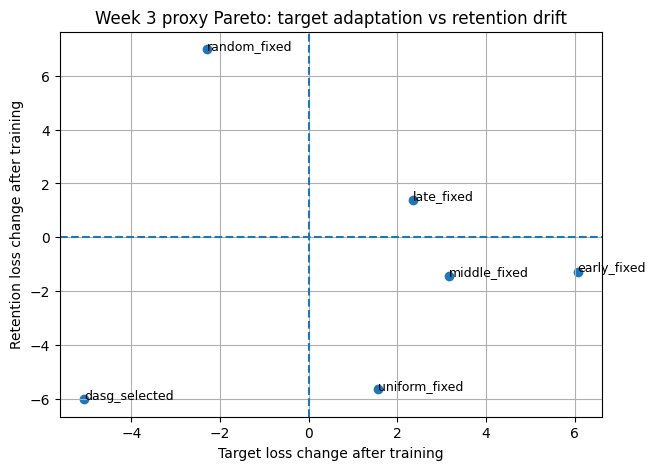

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    proxy["loss_change_after_minus_before_target"],
    proxy["loss_change_after_minus_before_retention"],
)

for _, row in proxy.iterrows():
    plt.text(
        row["loss_change_after_minus_before_target"],
        row["loss_change_after_minus_before_retention"],
        row["strategy"],
        fontsize=9,
    )

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.xlabel("Target loss change after training")
plt.ylabel("Retention loss change after training")
plt.title("Week 3 proxy Pareto: target adaptation vs retention drift")
plt.grid(True)
plt.show()

More left = better target adaptation.
Lower / closer to zero = better retention.

In [ ]:
best_strategy = proxy.iloc[0]["strategy"]

week3_report = {
    "week": 3,
    "task": "DASG layer-selection sweep proxy",
    "model": MODEL_NAME,
    "gpu": torch.cuda.get_device_name(0),
    "max_length": MAX_LENGTH,
    "train_steps_per_strategy": TRAIN_STEPS,
    "strategies": STRATEGIES,
    "best_proxy_strategy": best_strategy,
    "outputs": {
        "eval_log": str(eval_path),
        "train_log": str(train_path),
        "strategy_summary": str(summary_path),
        "before_after_loss_change": str(pivot_path),
        "proxy_pareto_table": str(proxy_path),
        "strategy_meta": str(meta_path),
    },
    "notes": (
        "This is a T4-friendly proxy for Week 3 DASG sweeps. "
        "Instead of full DiffusionGrow layer growth, LoRA adapters were attached "
        "to different layer groups: DASG-selected, early, middle, late, uniform, and random. "
        "Each strategy was trained briefly on target-domain toy code examples, then evaluated "
        "on both target and retention examples."
    ),
}

report_path = WEEK3_DIR / "week3_reproducibility_report.json"

with open(report_path, "w") as f:
    json.dump(week3_report, f, indent=2)

print("Saved:", report_path)
print(json.dumps(week3_report, indent=2))

Saved: /content/week3_dasg_sweeps/week3_reproducibility_report.json
{
  "week": 3,
  "task": "DASG layer-selection sweep proxy",
  "model": "inclusionAI/LLaDA-MoE-7B-A1B-Instruct",
  "gpu": "Tesla T4",
  "max_length": 32,
  "train_steps_per_strategy": 5,
  "strategies": {
    "dasg_selected": [
      15,
      14,
      13,
      12,
      11
    ],
    "early_fixed": [
      0,
      1,
      2,
      3,
      4
    ],
    "middle_fixed": [
      5,
      6,
      7,
      8,
      9
    ],
    "late_fixed": [
      11,
      12,
      13,
      14,
      15
    ],
    "uniform_fixed": [
      0,
      3,
      7,
      11,
      15
    ],
    "random_fixed": [
      0,
      3,
      4,
      11,
      15
    ]
  },
  "best_proxy_strategy": "dasg_selected",
  "outputs": {
    "eval_log": "/content/week3_dasg_sweeps/week3_strategy_eval_log.csv",
    "train_log": "/content/week3_dasg_sweeps/week3_strategy_train_log.csv",
    "strategy_summary": "/content/week3_dasg_sweeps/week3_strateg

Week 4: NoR-Gate Proxy on Free Colab T4

In [1]:
!pip -q install \
  "transformers>=4.45.0,<5.0.0" \
  "bitsandbytes>=0.46.1" \
  accelerate \
  peft \
  safetensors \
  sentencepiece \
  einops \
  pandas \
  matplotlib \
  numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 121.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "inclusionAI/LLaDA-MoE-7B-A1B-Instruct"
MASK_ID = 156895
MAX_LENGTH = 32

WEEK4_DIR = Path("/content/week4_norgate_proxy")
WEEK4_DIR.mkdir(parents=True, exist_ok=True)

# Use your Week 2 DASG-selected layers
DASG_SELECTED_LAYERS = [15, 14, 13, 12, 11]

TRAIN_STEPS = 5
LR = 2e-4

NOISE_BINS = {
    "low_noise": 0.15,
    "mid_noise": 0.50,
    "high_noise": 0.85,
}

TARGET_TEXTS = [
    "def add_numbers(a, b): return a + b",
    "for i in range(n): total += arr[i]",
    "A binary search repeatedly halves the search interval.",
    "The function computes the maximum subarray sum using dynamic programming.",
    "class Queue: def __init__(self): self.items = []",
]

RETENTION_TEXTS = [
    "The city library opens every morning.",
    "Students learn better when examples are clear and practice is consistent.",
    "A healthy diet includes fruits, vegetables, grains, and enough water.",
]

print("Week 4 dir:", WEEK4_DIR)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Week 4 dir: /content/week4_norgate_proxy
GPU: Tesla T4


In [3]:
RETENTION_SCHEDULES = {
    # Control: target adaptation only, no retention protection
    "no_retention": {
        "low_noise": 0.0,
        "mid_noise": 0.0,
        "high_noise": 0.0,
    },

    # Fixed retention weight, similar to the fixed-lambda baseline idea
    "fixed_0_5": {
        "low_noise": 0.5,
        "mid_noise": 0.5,
        "high_noise": 0.5,
    },

    # NoR-Gate style schedule:
    # high-noise gets strongest retention, low-noise gets more target plasticity
    "noise_conditional": {
        "low_noise": 0.1,
        "mid_noise": 0.5,
        "high_noise": 1.0,
    },

    # Strong retention everywhere, expected to preserve more but adapt less
    "strong_retention": {
        "low_noise": 1.0,
        "mid_noise": 1.0,
        "high_noise": 1.0,
    },
}

print(json.dumps(RETENTION_SCHEDULES, indent=2))

{
  "no_retention": {
    "low_noise": 0.0,
    "mid_noise": 0.0,
    "high_noise": 0.0
  },
  "fixed_0_5": {
    "low_noise": 0.5,
    "mid_noise": 0.5,
    "high_noise": 0.5
  },
  "noise_conditional": {
    "low_noise": 0.1,
    "mid_noise": 0.5,
    "high_noise": 1.0
  },
  "strong_retention": {
    "low_noise": 1.0,
    "mid_noise": 1.0,
    "high_noise": 1.0
  }
}


In [4]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

print("Tokenizer loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Tokenizer loaded.


In [5]:
def cleanup_model():
    global model

    try:
        del model
    except Exception:
        pass

    gc.collect()
    torch.cuda.empty_cache()


def load_base_model():
    cleanup_model()

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    base = AutoModel.from_pretrained(
        MODEL_NAME,
        trust_remote_code=True,
        quantization_config=bnb_config,
        device_map="auto",
        max_memory={
            0: "13GiB",
            "cpu": "25GiB",
        },
        low_cpu_mem_usage=True,
    )

    base.eval()
    return base


def get_input_device(model):
    try:
        return model.get_input_embeddings().weight.device
    except Exception:
        pass

    if hasattr(model, "device"):
        return model.device

    for p in model.parameters():
        return p.device

    return torch.device("cuda")

In [6]:
def encode_text(text, model):
    input_device = get_input_device(model)

    batch = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )

    input_ids = batch["input_ids"].to(input_device)

    if "attention_mask" in batch:
        attention_mask = batch["attention_mask"].to(input_device)
    else:
        attention_mask = torch.ones_like(input_ids)

    return input_ids, attention_mask


def make_masked_input(clean_ids, attention_mask, mask_prob):
    rand = torch.rand(clean_ids.shape, device=clean_ids.device)
    valid = attention_mask.bool()

    masked_indices = (rand < mask_prob) & valid

    if not masked_indices.any():
        masked_indices[0, -1] = True

    noisy_ids = torch.where(
        masked_indices,
        torch.full_like(clean_ids, MASK_ID),
        clean_ids,
    )

    return noisy_ids, masked_indices


def get_logits_from_output(out):
    if hasattr(out, "logits"):
        return out.logits

    if isinstance(out, (tuple, list)):
        return out[0]

    return out


def forward_logits(model, input_ids):
    out = model(input_ids=input_ids)
    return get_logits_from_output(out)


def gpu_mem_gb():
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.max_memory_allocated() / 1024**3

In [7]:
def extract_layer_id(module_name):
    parts = module_name.split(".")

    for i, part in enumerate(parts):
        if part in ["layers", "blocks", "h", "decoder_layers"]:
            if i + 1 < len(parts) and parts[i + 1].isdigit():
                return int(parts[i + 1])

    for part in parts:
        if part.isdigit():
            value = int(part)
            if 0 <= value <= 100:
                return value

    return None


def find_lora_modules_for_layers(model, selected_layers):
    selected_layers = set(selected_layers)

    preferred_leaf_names = {
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "up_proj",
        "down_proj",
        "gate_proj",
    }

    target_module_names = []

    for name, module in model.named_modules():
        cls_name = module.__class__.__name__.lower()
        leaf = name.split(".")[-1]

        is_linear_like = "linear" in cls_name
        layer_id = extract_layer_id(name)

        if (
            is_linear_like
            and layer_id in selected_layers
            and leaf in preferred_leaf_names
        ):
            target_module_names.append(name)

    return sorted(target_module_names)


def attach_lora_to_dasg_layers(base_model):
    target_modules = find_lora_modules_for_layers(
        base_model,
        DASG_SELECTED_LAYERS,
    )

    if len(target_modules) == 0:
        raise RuntimeError("No LoRA target modules found for DASG-selected layers.")

    base_model = prepare_model_for_kbit_training(base_model)

    lora_config = LoraConfig(
        r=4,
        lora_alpha=8,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
    )

    peft_model = get_peft_model(base_model, lora_config)

    return peft_model, target_modules

base model output = LoRA disabled
probe output = LoRA enabled

In [8]:
from contextlib import nullcontext

def adapter_disabled_context(model):
    if hasattr(model, "disable_adapter"):
        return model.disable_adapter()
    return nullcontext()

In [9]:
def compute_target_ce_loss(model, text, noise_bin, mask_prob):
    input_ids, attention_mask = encode_text(text, model)

    noisy_ids, masked_indices = make_masked_input(
        input_ids,
        attention_mask,
        mask_prob,
    )

    logits = forward_logits(model, noisy_ids).float()

    logits_masked = logits[masked_indices]
    labels_masked = input_ids[masked_indices]

    ce_loss = F.cross_entropy(logits_masked, labels_masked)
    weighted_loss = ce_loss / mask_prob

    return weighted_loss, ce_loss, int(masked_indices.sum().item())


def compute_retention_kl_loss(model, text, mask_prob):
    input_ids, attention_mask = encode_text(text, model)

    noisy_ids, masked_indices = make_masked_input(
        input_ids,
        attention_mask,
        mask_prob,
    )

    with torch.no_grad():
        with adapter_disabled_context(model):
            base_logits = forward_logits(model, noisy_ids).float()

    probe_logits = forward_logits(model, noisy_ids).float()

    if masked_indices.sum().item() == 0:
        return torch.tensor(0.0, device=get_input_device(model)), 0

    base_log_probs = F.log_softmax(base_logits[masked_indices], dim=-1)
    probe_log_probs = F.log_softmax(probe_logits[masked_indices], dim=-1)
    base_probs = base_log_probs.exp()

    # KL(base || probe), optimized through probe logits only
    kl_loss = F.kl_div(
        probe_log_probs,
        base_probs,
        reduction="batchmean",
    )

    weighted_kl = kl_loss / mask_prob

    return weighted_kl, int(masked_indices.sum().item())

In [10]:
@torch.no_grad()
def eval_domain_loss(model, texts, domain_name):
    model.eval()

    rows = []

    for text in texts:
        for noise_bin, mask_prob in NOISE_BINS.items():
            input_ids, attention_mask = encode_text(text, model)

            noisy_ids, masked_indices = make_masked_input(
                input_ids,
                attention_mask,
                mask_prob,
            )

            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()

            start = time.time()

            logits = forward_logits(model, noisy_ids).float()

            elapsed = time.time() - start

            logits_masked = logits[masked_indices]
            labels_masked = input_ids[masked_indices]

            ce_loss = F.cross_entropy(logits_masked, labels_masked)
            weighted_loss = ce_loss / mask_prob

            # Teacher agreement proxy: agreement between base-disabled and current adapter predictions
            with adapter_disabled_context(model):
                base_logits = forward_logits(model, noisy_ids).float()

            base_pred = base_logits.argmax(dim=-1)
            probe_pred = logits.argmax(dim=-1)

            if masked_indices.sum().item() > 0:
                teacher_agreement = (
                    base_pred[masked_indices] == probe_pred[masked_indices]
                ).float().mean().item()
            else:
                teacher_agreement = float("nan")

            rows.append({
                "domain": domain_name,
                "text": text,
                "noise_bin": noise_bin,
                "mask_prob": mask_prob,
                "ce_loss": float(ce_loss.detach().cpu()),
                "weighted_loss": float(weighted_loss.detach().cpu()),
                "teacher_agreement": teacher_agreement,
                "masked_tokens": int(masked_indices.sum().item()),
                "peak_gpu_memory_gb": gpu_mem_gb(),
                "elapsed_sec": elapsed,
            })

            del noisy_ids, masked_indices, logits, base_logits
            torch.cuda.empty_cache()

    return rows

In [11]:
def train_norgate_schedule(model, schedule_name, schedule):
    model.train()

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR,
    )

    train_rows = []

    for step in range(TRAIN_STEPS):
        noise_bin = random.choice(list(NOISE_BINS.keys()))
        mask_prob = NOISE_BINS[noise_bin]
        lambda_ret = schedule[noise_bin]

        target_text = random.choice(TARGET_TEXTS)
        retention_text = random.choice(RETENTION_TEXTS)

        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        start = time.time()

        target_loss, target_ce, target_masked = compute_target_ce_loss(
            model,
            target_text,
            noise_bin,
            mask_prob,
        )

        if lambda_ret > 0:
            retention_kl, retention_masked = compute_retention_kl_loss(
                model,
                retention_text,
                mask_prob,
            )
        else:
            retention_kl = torch.tensor(0.0, device=get_input_device(model))
            retention_masked = 0

        total_loss = target_loss + lambda_ret * retention_kl

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        elapsed = time.time() - start

        row = {
            "schedule": schedule_name,
            "step": step,
            "noise_bin": noise_bin,
            "mask_prob": mask_prob,
            "lambda_ret": lambda_ret,
            "target_text": target_text,
            "retention_text": retention_text,
            "target_ce_loss": float(target_ce.detach().cpu()),
            "target_weighted_loss": float(target_loss.detach().cpu()),
            "retention_kl_loss": float(retention_kl.detach().cpu()),
            "total_loss": float(total_loss.detach().cpu()),
            "target_masked_tokens": target_masked,
            "retention_masked_tokens": retention_masked,
            "peak_gpu_memory_gb": gpu_mem_gb(),
            "elapsed_sec": elapsed,
        }

        train_rows.append(row)
        print(row)

        torch.cuda.empty_cache()

    return train_rows

In [12]:
schedule_name = "noise_conditional"
schedule = RETENTION_SCHEDULES[schedule_name]

cleanup_model()

model = load_base_model()
model, target_modules = attach_lora_to_dasg_layers(model)

print("Running schedule:", schedule_name)
print("DASG layers:", DASG_SELECTED_LAYERS)
print("Number of LoRA modules:", len(target_modules))

model.print_trainable_parameters()

before_rows = []
before_rows += eval_domain_loss(model, TARGET_TEXTS, "target_code_toy_before")
before_rows += eval_domain_loss(model, RETENTION_TEXTS, "retention_general_toy_before")

train_rows = train_norgate_schedule(model, schedule_name, schedule)

after_rows = []
after_rows += eval_domain_loss(model, TARGET_TEXTS, "target_code_toy_after")
after_rows += eval_domain_loss(model, RETENTION_TEXTS, "retention_general_toy_after")

test_eval_df = pd.DataFrame(before_rows + after_rows)
test_train_df = pd.DataFrame(train_rows)

display(test_train_df)
display(test_eval_df.head())

config.json: 0.00B [00:00, ?B/s]

configuration_lladamoe.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/inclusionAI/LLaDA-MoE-7B-A1B-Instruct:
- configuration_lladamoe.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_lladamoe.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/inclusionAI/LLaDA-MoE-7B-A1B-Instruct:
- modeling_lladamoe.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

Running schedule: noise_conditional
DASG layers: [15, 14, 13, 12, 11]
Number of LoRA modules: 980
trainable params: 12,124,160 || all params: 7,369,005,056 || trainable%: 0.1645


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


{'schedule': 'noise_conditional', 'step': 0, 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'lambda_ret': 1.0, 'target_text': 'def add_numbers(a, b): return a + b', 'retention_text': 'The city library opens every morning.', 'target_ce_loss': 5.353320121765137, 'target_weighted_loss': 6.298023700714111, 'retention_kl_loss': -5.843593164911454e-09, 'total_loss': 6.298023700714111, 'target_masked_tokens': 10, 'retention_masked_tokens': 6, 'peak_gpu_memory_gb': 5.871907711029053, 'elapsed_sec': 7.826500415802002}
{'schedule': 'noise_conditional', 'step': 1, 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'lambda_ret': 1.0, 'target_text': 'A binary search repeatedly halves the search interval.', 'retention_text': 'The city library opens every morning.', 'target_ce_loss': 8.860881805419922, 'target_weighted_loss': 10.424567222595215, 'retention_kl_loss': 4.3503885535756126e-05, 'total_loss': 10.42461109161377, 'target_masked_tokens': 9, 'retention_masked_tokens': 6, 'peak_gpu_memory_gb': 5.8718

,schedule,step,noise_bin,mask_prob,lambda_ret,target_text,retention_text,target_ce_loss,target_weighted_loss,retention_kl_loss,total_loss,target_masked_tokens,retention_masked_tokens,peak_gpu_memory_gb,elapsed_sec
0,noise_conditional,0,high_noise,0.85,1.0,"def add_numbers(a, b): return a + b",The city library opens every morning.,5.353320,6.298024,-5.843593e-09,6.298024,10,6,5.871908,7.826500
1,noise_conditional,1,high_noise,0.85,1.0,A binary search repeatedly halves the search i...,The city library opens every morning.,8.860882,10.424567,4.350389e-05,10.424611,9,6,5.871875,7.076331
2,noise_conditional,2,low_noise,0.15,0.1,for i in range(n): total += arr[i],"A healthy diet includes fruits, vegetables, gr...",2.844678,18.964521,1.761333e-04,18.964539,1,2,5.872021,9.530678
3,noise_conditional,3,low_noise,0.15,0.1,class Queue: def __init__(self): self.items = [],The city library opens every morning.,1.638880,10.925867,1.366634e-03,10.926003,3,1,5.871940,8.754145
4,noise_conditional,4,high_noise,0.85,1.0,The function computes the maximum subarray sum...,The city library opens every morning.,7.926333,9.325099,5.805927e-04,9.325680,10,5,5.871924,8.659988


,domain,text,noise_bin,mask_prob,ce_loss,weighted_loss,teacher_agreement,masked_tokens,peak_gpu_memory_gb,elapsed_sec
0,target_code_toy_before,"def add_numbers(a, b): return a + b",low_noise,0.15,2.545376,16.969175,1.0,2,5.699328,2.281221
1,target_code_toy_before,"def add_numbers(a, b): return a + b",mid_noise,0.50,5.294236,10.588472,1.0,1,5.698743,1.044230
2,target_code_toy_before,"def add_numbers(a, b): return a + b",high_noise,0.85,7.128856,8.386890,1.0,9,5.703428,1.321424
3,target_code_toy_before,for i in range(n): total += arr[i],low_noise,0.15,0.324993,2.166617,1.0,3,5.699914,1.088977
4,target_code_toy_before,for i in range(n): total += arr[i],mid_noise,0.50,2.847755,5.695511,1.0,7,5.702257,1.031091


In [13]:
TRAIN_STEPS = 3

In [14]:
all_eval_rows = []
all_train_rows = []
schedule_meta = []

for schedule_name, schedule in RETENTION_SCHEDULES.items():
    print("=" * 80)
    print("Starting schedule:", schedule_name)
    print(schedule)

    cleanup_model()

    model = load_base_model()
    model, target_modules = attach_lora_to_dasg_layers(model)

    model.print_trainable_parameters()

    schedule_meta.append({
        "schedule": schedule_name,
        "lambda_by_noise_bin": schedule,
        "dasg_selected_layers": DASG_SELECTED_LAYERS,
        "num_lora_target_modules": len(target_modules),
        "target_modules_sample": target_modules[:10],
    })

    before_rows = []
    before_rows += eval_domain_loss(model, TARGET_TEXTS, "target_code_toy_before")
    before_rows += eval_domain_loss(model, RETENTION_TEXTS, "retention_general_toy_before")

    for row in before_rows:
        row["schedule"] = schedule_name
        row["lambda_by_noise_bin"] = str(schedule)

    train_rows = train_norgate_schedule(model, schedule_name, schedule)

    after_rows = []
    after_rows += eval_domain_loss(model, TARGET_TEXTS, "target_code_toy_after")
    after_rows += eval_domain_loss(model, RETENTION_TEXTS, "retention_general_toy_after")

    for row in after_rows:
        row["schedule"] = schedule_name
        row["lambda_by_noise_bin"] = str(schedule)

    all_eval_rows.extend(before_rows)
    all_eval_rows.extend(after_rows)
    all_train_rows.extend(train_rows)

    # Save partial results after each schedule
    pd.DataFrame(all_eval_rows).to_csv(
        WEEK4_DIR / "week4_eval_partial.csv",
        index=False,
    )

    pd.DataFrame(all_train_rows).to_csv(
        WEEK4_DIR / "week4_train_partial.csv",
        index=False,
    )

    print("Partial saved.")

    cleanup_model()

eval_df = pd.DataFrame(all_eval_rows)
train_df = pd.DataFrame(all_train_rows)

eval_path = WEEK4_DIR / "week4_norgate_eval_log.csv"
train_path = WEEK4_DIR / "week4_norgate_train_log.csv"
meta_path = WEEK4_DIR / "week4_schedule_meta.json"

eval_df.to_csv(eval_path, index=False)
train_df.to_csv(train_path, index=False)

with open(meta_path, "w") as f:
    json.dump(schedule_meta, f, indent=2)

print("Saved:", eval_path)
print("Saved:", train_path)
print("Saved:", meta_path)

display(eval_df.head())
display(train_df.head())

Starting schedule: no_retention
{'low_noise': 0.0, 'mid_noise': 0.0, 'high_noise': 0.0}


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 12,124,160 || all params: 7,369,005,056 || trainable%: 0.1645


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


...

trainable params: 12,124,160 || all params: 7,369,005,056 || trainable%: 0.1645
{'schedule': 'noise_conditional', 'step': 0, 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'lambda_ret': 1.0, 'target_text': 'The function computes the maximum subarray sum using dynamic programming.', 'retention_text': 'Students learn better when examples are clear and practice is consistent.', 'target_ce_loss': 7.917093753814697, 'target_weighted_loss': 9.314228057861328, 'retention_kl_loss': 0.0, 'total_loss': 9.314228057861328, 'target_masked_tokens': 10, 'retention_masked_tokens': 10, 'peak_gpu_memory_gb': 5.872004985809326, 'elapsed_sec': 9.405017375946045}
{'schedule': 'noise_conditional', 'step': 1, 'noise_bin': 'mid_noise', 'mask_prob': 0.5, 'lambda_ret': 0.5, 'target_text': 'for i in range(n): total += arr[i]', 'retention_text': 'The city library opens every morning.', 'target_ce_loss': 1.1269466876983643, 'target_weighted_loss': 2.2538933753967285, 'retention_kl_loss': 0.00028930947883054614, 'to

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

trainable params: 12,124,160 || all params: 7,369,005,056 || trainable%: 0.1645
{'schedule': 'strong_retention', 'step': 0, 'noise_bin': 'mid_noise', 'mask_prob': 0.5, 'lambda_ret': 1.0, 'target_text': 'def add_numbers(a, b): return a + b', 'retention_text': 'Students learn better when examples are clear and practice is consistent.', 'target_ce_loss': 0.45935845375061035, 'target_weighted_loss': 0.9187169075012207, 'retention_kl_loss': 2.3841858265427618e-08, 'total_loss': 0.9187169075012207, 'target_masked_tokens': 6, 'retention_masked_tokens': 5, 'peak_gpu_memory_gb': 5.871988773345947, 'elapsed_sec': 10.118480682373047}
{'schedule': 'strong_retention', 'step': 1, 'noise_bin': 'mid_noise', 'mask_prob': 0.5, 'lambda_ret': 1.0, 'target_text': 'class Queue: def __init__(self): self.items = []', 'retention_text': 'Students learn better when examples are clear and practice is consistent.', 'target_ce_loss': 2.4675512313842773, 'target_weighted_loss': 4.935102462768555, 'retention_kl_loss'

,domain,text,noise_bin,mask_prob,ce_loss,weighted_loss,teacher_agreement,masked_tokens,peak_gpu_memory_gb,elapsed_sec,schedule,lambda_by_noise_bin
0,target_code_toy_before,"def add_numbers(a, b): return a + b",low_noise,0.15,0.067126,0.447505,1.0,1,5.706677,1.461385,no_retention,"{'low_noise': 0.0, 'mid_noise': 0.0, 'high_noi..."
1,target_code_toy_before,"def add_numbers(a, b): return a + b",mid_noise,0.50,4.103748,8.207496,1.0,5,5.709020,1.074688,no_retention,"{'low_noise': 0.0, 'mid_noise': 0.0, 'high_noi..."
2,target_code_toy_before,"def add_numbers(a, b): return a + b",high_noise,0.85,5.969582,7.023038,1.0,8,5.710777,0.994690,no_retention,"{'low_noise': 0.0, 'mid_noise': 0.0, 'high_noi..."
3,target_code_toy_before,for i in range(n): total += arr[i],low_noise,0.15,2.374278,15.828517,1.0,1,5.706678,1.078375,no_retention,"{'low_noise': 0.0, 'mid_noise': 0.0, 'high_noi..."
4,target_code_toy_before,for i in range(n): total += arr[i],mid_noise,0.50,3.812600,7.625200,1.0,6,5.709606,1.044790,no_retention,"{'low_noise': 0.0, 'mid_noise': 0.0, 'high_noi..."


,schedule,step,noise_bin,mask_prob,lambda_ret,target_text,retention_text,target_ce_loss,target_weighted_loss,retention_kl_loss,total_loss,target_masked_tokens,retention_masked_tokens,peak_gpu_memory_gb,elapsed_sec
0,no_retention,0,low_noise,0.15,0.0,"def add_numbers(a, b): return a + b",The city library opens every morning.,0.028403,0.189350,0.000000,0.189350,2,0,5.871794,6.712557
1,no_retention,1,low_noise,0.15,0.0,class Queue: def __init__(self): self.items = [],"A healthy diet includes fruits, vegetables, gr...",0.801639,5.344257,0.000000,5.344257,3,0,5.871827,10.358409
2,no_retention,2,low_noise,0.15,0.0,class Queue: def __init__(self): self.items = [],The city library opens every morning.,4.166310,27.775398,0.000000,27.775398,3,0,5.871827,4.060554
3,fixed_0_5,0,high_noise,0.85,0.5,class Queue: def __init__(self): self.items = [],Students learn better when examples are clear ...,2.735232,3.217920,0.000000,3.217920,11,9,5.872021,9.274928
4,fixed_0_5,1,low_noise,0.15,0.5,The function computes the maximum subarray sum...,"A healthy diet includes fruits, vegetables, gr...",2.277820,15.185467,0.000062,15.185498,2,2,5.872037,9.502516


In [15]:
def split_phase(domain):
    if domain.endswith("_before"):
        return "before"
    if domain.endswith("_after"):
        return "after"
    return "unknown"


def clean_domain(domain):
    return domain.replace("_before", "").replace("_after", "")


eval_df["phase"] = eval_df["domain"].apply(split_phase)
eval_df["clean_domain"] = eval_df["domain"].apply(clean_domain)

phase_summary = (
    eval_df
    .groupby(["schedule", "clean_domain", "phase"])
    .agg(
        mean_ce_loss=("ce_loss", "mean"),
        mean_weighted_loss=("weighted_loss", "mean"),
        mean_teacher_agreement=("teacher_agreement", "mean"),
        max_gpu_memory_gb=("peak_gpu_memory_gb", "max"),
    )
    .reset_index()
)

summary_path = WEEK4_DIR / "week4_phase_summary.csv"
phase_summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(phase_summary)

Saved: /content/week4_norgate_proxy/week4_phase_summary.csv


,schedule,clean_domain,phase,mean_ce_loss,mean_weighted_loss,mean_teacher_agreement,max_gpu_memory_gb
0,fixed_0_5,retention_general_toy,after,4.976818,13.333278,0.979798,5.759045
1,fixed_0_5,retention_general_toy,before,5.237486,11.964208,1.000000,5.714465
2,fixed_0_5,target_code_toy,after,4.974994,12.192396,0.993333,5.758987
3,fixed_0_5,target_code_toy,before,3.954435,6.983874,1.000000,5.714992
4,no_retention,retention_general_toy,after,5.793589,12.366742,0.981481,5.760802
5,no_retention,retention_general_toy,before,4.509647,9.046823,1.000000,5.716221
6,no_retention,target_code_toy,after,3.939868,7.749903,1.000000,5.758987
7,no_retention,target_code_toy,before,3.410425,5.976973,1.000000,5.713235
8,noise_conditional,retention_general_toy,after,5.228406,11.081843,0.958995,5.760802
9,noise_conditional,retention_general_toy,before,4.197791,8.371814,1.000000,5.714465


In [16]:
pivot = phase_summary.pivot_table(
    index=["schedule", "clean_domain"],
    columns="phase",
    values="mean_weighted_loss",
).reset_index()

pivot["loss_change_after_minus_before"] = pivot["after"] - pivot["before"]

pivot_path = WEEK4_DIR / "week4_before_after_loss_change.csv"
pivot.to_csv(pivot_path, index=False)

print("Saved:", pivot_path)
display(pivot)

Saved: /content/week4_norgate_proxy/week4_before_after_loss_change.csv


phase,schedule,clean_domain,after,before,loss_change_after_minus_before
0,fixed_0_5,retention_general_toy,13.333278,11.964208,1.369070
1,fixed_0_5,target_code_toy,12.192396,6.983874,5.208522
2,no_retention,retention_general_toy,12.366742,9.046823,3.319919
3,no_retention,target_code_toy,7.749903,5.976973,1.772930
4,noise_conditional,retention_general_toy,11.081843,8.371814,2.710028
5,noise_conditional,target_code_toy,8.258745,6.516613,1.742132
6,strong_retention,retention_general_toy,9.447386,8.331864,1.115522
7,strong_retention,target_code_toy,8.366607,6.771119,1.595487


Target loss change: more negative is better.
Retention loss change: closer to zero or negative is better.

In [17]:
target_rows = pivot[pivot["clean_domain"] == "target_code_toy"].copy()
retention_rows = pivot[pivot["clean_domain"] == "retention_general_toy"].copy()

proxy = target_rows.merge(
    retention_rows,
    on="schedule",
    suffixes=("_target", "_retention"),
)

proxy = proxy[[
    "schedule",
    "loss_change_after_minus_before_target",
    "loss_change_after_minus_before_retention",
]]

proxy = proxy.sort_values(
    [
        "loss_change_after_minus_before_target",
        "loss_change_after_minus_before_retention",
    ],
    ascending=[True, True],
)

proxy_path = WEEK4_DIR / "week4_proxy_pareto_table.csv"
proxy.to_csv(proxy_path, index=False)

print("Saved:", proxy_path)
display(proxy)

Saved: /content/week4_norgate_proxy/week4_proxy_pareto_table.csv


phase,schedule,loss_change_after_minus_before_target,loss_change_after_minus_before_retention
3,strong_retention,1.595487,1.115522
2,noise_conditional,1.742132,2.710028
1,no_retention,1.772930,3.319919
0,fixed_0_5,5.208522,1.369070


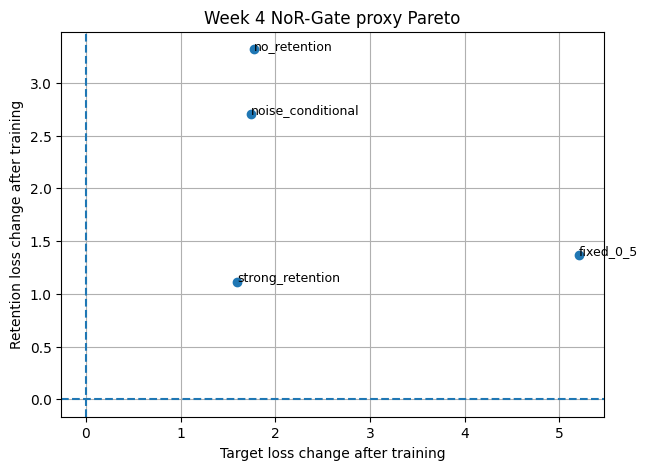

In [18]:
plt.figure(figsize=(7, 5))

plt.scatter(
    proxy["loss_change_after_minus_before_target"],
    proxy["loss_change_after_minus_before_retention"],
)

for _, row in proxy.iterrows():
    plt.text(
        row["loss_change_after_minus_before_target"],
        row["loss_change_after_minus_before_retention"],
        row["schedule"],
        fontsize=9,
    )

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.xlabel("Target loss change after training")
plt.ylabel("Retention loss change after training")
plt.title("Week 4 NoR-Gate proxy Pareto")
plt.grid(True)
plt.show()

In [19]:
best_schedule = proxy.iloc[0]["schedule"]

week4_report = {
    "week": 4,
    "task": "NoR-Gate noise-conditional retention proxy",
    "model": MODEL_NAME,
    "gpu": torch.cuda.get_device_name(0),
    "max_length": MAX_LENGTH,
    "dasg_selected_layers": DASG_SELECTED_LAYERS,
    "train_steps_per_schedule": TRAIN_STEPS,
    "retention_schedules": RETENTION_SCHEDULES,
    "best_proxy_schedule": best_schedule,
    "outputs": {
        "eval_log": str(eval_path),
        "train_log": str(train_path),
        "schedule_meta": str(meta_path),
        "phase_summary": str(summary_path),
        "before_after_loss_change": str(pivot_path),
        "proxy_pareto_table": str(proxy_path),
    },
    "notes": (
        "This is a T4-friendly proxy for NoR-Gate. "
        "The full DiffusionGrow gate regularizer is not implemented because vanilla LLaDA-MoE "
        "does not contain grown branches or gates. Instead, this experiment compares fixed and "
        "noise-conditioned retention schedules using KL(base || adapted LoRA) as the retention loss."
    ),
}

report_path = WEEK4_DIR / "week4_reproducibility_report.json"

with open(report_path, "w") as f:
    json.dump(week4_report, f, indent=2)

print("Saved:", report_path)
print(json.dumps(week4_report, indent=2))

Saved: /content/week4_norgate_proxy/week4_reproducibility_report.json
{
  "week": 4,
  "task": "NoR-Gate noise-conditional retention proxy",
  "model": "inclusionAI/LLaDA-MoE-7B-A1B-Instruct",
  "gpu": "Tesla T4",
  "max_length": 32,
  "dasg_selected_layers": [
    15,
    14,
    13,
    12,
    11
  ],
  "train_steps_per_schedule": 3,
  "retention_schedules": {
    "no_retention": {
      "low_noise": 0.0,
      "mid_noise": 0.0,
      "high_noise": 0.0
    },
    "fixed_0_5": {
      "low_noise": 0.5,
      "mid_noise": 0.5,
      "high_noise": 0.5
    },
    "noise_conditional": {
      "low_noise": 0.1,
      "mid_noise": 0.5,
      "high_noise": 1.0
    },
    "strong_retention": {
      "low_noise": 1.0,
      "mid_noise": 1.0,
      "high_noise": 1.0
    }
  },
  "best_proxy_schedule": "strong_retention",
  "outputs": {
    "eval_log": "/content/week4_norgate_proxy/week4_norgate_eval_log.csv",
    "train_log": "/content/week4_norgate_proxy/week4_norgate_train_log.csv",
    "sch

Week 4 implemented a NoR-Gate proxy experiment on top of the Week 3 DASG-selected layers. Since the current baseline uses vanilla LLaDA-MoE without DiffusionGrow gates, the experiment focused on the noise-conditional retention component of NoR-Gate. A LoRA adapter was attached to the DASG-selected layers and trained under four schedules: no retention, fixed retention, noise-conditioned retention, and strong retention. The retention loss was implemented as KL(base || adapted LoRA) on masked general-domain examples, while the target loss was masked denoising cross-entropy on toy code examples. The run compared target-loss improvement against retention-loss change and saved a proxy Pareto table and reproducibility report.